# Non-reversible anchored Langevin with block state-dependent skew-symmetric matrices

**Constrained Bayesian logistic regression on MAGIC Gamma Telescope and Titanic.**

This notebook implements and compares four constrained stochastic-gradient samplers on a
uniform-prior Bayesian logistic-regression posterior restricted to a compact set $K\subset\mathbb R^9$:

| Method | $\rho$ | $\alpha$ |
|---|---:|---:|
| Projected SGLD | $0$ | $0$ |
| Non-reversible SGLD | $0$ | $1$ |
| Reversible anchored Langevin | $\log 2$ | $0$ |
| Non-reversible anchored Langevin | $\log 2$ | $1$ |

All four are the *same* code path; only $(\rho,\alpha)$ change. The common update is

$$\beta_{k+1}=\Pi_K\!\left[\beta_k-h\,a_k\big(v_k+\alpha J(\beta_k)v_k\big)+\sqrt{2ha_k}\,\xi_k\right],\qquad
a_k=e^{-\rho H_K(\beta_k)},\quad \xi_k\sim N(0,I_9),$$

with $v_k=\widehat G_k+\rho\nabla H_K(\beta_k)$ and $\widehat G_k$ the $n_{\rm train}/m$-rescaled
mini-batch likelihood gradient.

---

## Declared design choices (not verified reconstructions of the source)

1. **MAGIC nine-feature preprocessing.** The source does not specify how ten raw MAGIC predictors
   become nine coefficients. We use a training-only `StandardScaler` followed by a training-only
   `PCA(n_components=9, svd_solver="full", whiten=False)`, and run the sampler on the nine PCA
   scores with no intercept. **This is our proposed choice, not a verified reconstruction.**
2. **Titanic nine-feature preprocessing.** The nine features (Age, SibSp, Parch, Fare, female,
   Pclass2, Pclass3, EmbarkedQ, EmbarkedS) with training-median imputation, training-fitted
   standardisation of the four numeric columns, and class-1 / embarkation-C references, are a
   **reproducible adaptation**, not a verified reconstruction.
3. **"100 samples".** The source's phrase is ambiguous. **Our interpretation:** $R=100$
   *independent sampler replicates* run on one fixed dataset and one fixed train/test split.
   The shaded bands are therefore **repeat-run variability conditional on that fixed split** --
   they are *not* confidence intervals and *not* posterior credible intervals.
4. **Bounded anchor.** $U_0=U+\rho H_K$ with $\rho=\log 2$ is an *algorithmic reference potential*
   chosen so that $a=e^{-\rho H_K}\in[\tfrac12,1]$ on $K$. It does **not** change the specified
   posterior $\pi_K\propto e^{-U}\mathbf 1_K$, and it carries **no guaranteed speed advantage**.
5. **Step size.** $h=10^{-4}$ is treated as the source's *reported candidate*, not as a verified
   accurate discretisation. Section 12 runs $h/2$ and $h/4$ at $2\times$ and $4\times$ the
   iteration count so that simulated time $t=kh$ is held fixed.

We do **not** presuppose that the proposed sampler outperforms its controls. Classification
accuracy measures prediction; on its own it demonstrates neither posterior convergence, nor
correct uncertainty quantification, nor faster mixing, nor reduced asymptotic variance.

---
## 1. Configuration

In [1]:
from __future__ import annotations

import dataclasses
import hashlib
import json
import math
import os
import platform
import sys
import time
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import scipy
import scipy.optimize
import sklearn
import matplotlib
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import rankdata
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:                       # inline figures inside Jupyter ...
    get_ipython().run_line_magic("matplotlib", "inline")          # type: ignore[name-defined]
except Exception:          # ... and a headless backend when this file is run as a script
    matplotlib.use("Agg")

DIM = 9                      # number of coefficients (no intercept)
BLOCKS = ((0, 1, 2), (3, 4, 5), (6, 7, 8))   # I_1 = (1,2,3), I_2 = (4,5,6), I_3 = (7,8,9), 0-indexed
BATCH_SIZE = 30              # m
TEST_SIZE = 0.2
SPLIT_SEED = 2027
SAMPLER_SEED = 3000
RHO_ANCHORED = math.log(2.0)
H_REPORTED = 1e-4            # the source's reported candidate step size

# Quick mode is a smoke test, NOT the experiment.
QUICK = os.environ.get("NRAL_MODE", "full").lower() == "quick"
N_REPLICATES = 5 if QUICK else 100
SENSITIVITY_REPLICATES = 3 if QUICK else 20      # configurable; disclosed in Section 12
CHECKPOINT_EVERY = 10

DATA_DIR = os.environ.get("NRAL_DATA_DIR", os.path.join(os.getcwd(), "data"))
RESULTS_DIR = os.environ.get("NRAL_RESULTS_DIR", os.path.join(os.getcwd(), "results"))
FIGURE_DIR = os.environ.get("NRAL_FIGURE_DIR", os.path.join(os.getcwd(), "figures"))
MAGIC_PATH = os.environ.get("NRAL_MAGIC_PATH", os.path.join(DATA_DIR, "magic04.data"))
TITANIC_PATH = os.environ.get("NRAL_TITANIC_PATH", os.path.join(DATA_DIR, "titanic_train.csv"))
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

METHODS = (
    # (key, display label, rho, alpha)
    ("psgld",   "Projected SGLD",                   0.0,           0),
    ("nrsgld",  "Non-reversible SGLD",              0.0,           1),
    ("ranch",   "Reversible anchored Langevin",     RHO_ANCHORED,  0),
    ("nranch",  "Non-reversible anchored Langevin", RHO_ANCHORED,  1),
)
METHOD_KEYS = tuple(m[0] for m in METHODS)
METHOD_LABEL = {m[0]: m[1] for m in METHODS}

STYLE = {   # consistent colours / line styles across every panel
    "psgld":  dict(color="0.45", linestyle="--",  linewidth=1.8, band="0.45"),
    "nrsgld": dict(color="#e08214", linestyle="-.", linewidth=1.8, band="#e08214"),
    "ranch":  dict(color="#1f5fbf", linestyle="-",  linewidth=1.8, band="#1f5fbf"),
    "nranch": dict(color="#1a9850", linestyle="-",  linewidth=1.8, band="#1a9850"),
}

FEASIBILITY_TOL = 1e-9


@dataclasses.dataclass(frozen=True)
class ExperimentSpec:
    key: str
    dataset: str                 # "magic" | "titanic"
    geometry_kind: str           # "ball" | "lp"
    n_iter: int
    block_scales: Tuple[float, float, float]
    figure_name: str
    # ball
    ball_r2: float = 2.0
    # smoothed l_p
    p: float = 2.4
    eps: float = 0.2
    Lam: float = 4.0


EXPERIMENTS = (
    ExperimentSpec("magic_ball",   "magic",   "ball", 1000 if not QUICK else 200, (5.0, 5.0, 5.0), "magic_ball_accuracy"),
    ExperimentSpec("magic_lp",     "magic",   "lp",   1000 if not QUICK else 200, (5.0, 5.0, 5.0), "magic_lp_accuracy",
                   p=2.4, eps=0.20, Lam=4.0),
    ExperimentSpec("titanic_ball", "titanic", "ball", 1500 if not QUICK else 200, (2.0, 7.0, 2.0), "titanic_ball_accuracy"),
    ExperimentSpec("titanic_lp",   "titanic", "lp",   2000 if not QUICK else 200, (2.0, 7.0, 2.0), "titanic_lp_accuracy",
                   p=2.4, eps=0.18, Lam=4.0),
)

PKG_VERSIONS = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "sklearn": sklearn.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
}

---
## 2. Data loading

**Network note for this run.** The official endpoints
`https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope` and
`https://www.kaggle.com/competitions/titanic/data` are **blocked by this execution
environment's outbound network policy** (the egress proxy rejects `archive.ics.uci.edu`,
`kaggle.com` and `openml.org`). The loaders below still *prefer* those official sources and
`ucimlrepo`; in this run they fell back to a public mirror, and every file was then validated
against the official schema (row counts, column names, class counts, missingness) before use.
Checksums of the exact bytes used are recorded in the saved configuration.

If neither a local file nor a reachable source is available, the loader raises with an
actionable message and the affected experiments are reported as **not run**. No data are
fabricated.

In [2]:
MAGIC_COLUMNS = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist",
]
MAGIC_N = 19020
MAGIC_CLASS_COUNTS = {"g": 12332, "h": 6688}

TITANIC_COLUMNS = [
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
]
TITANIC_N = 891


class DataUnavailable(RuntimeError):
    """Raised when a dataset cannot be obtained; the caller reports the experiment as not run."""


def _sha256(path: str) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def load_magic(path: str = MAGIC_PATH, allow_download: bool = True) -> Tuple[pd.DataFrame, pd.Series, dict]:
    """Load UCI MAGIC Gamma Telescope: 19020 x 10 predictors, class g -> 1, h -> 0."""
    prov: Dict[str, object] = {}
    if os.path.exists(path):
        df = pd.read_csv(path, header=None, names=MAGIC_COLUMNS + ["class"])
        prov.update(source="local file", path=path, sha256=_sha256(path))
    elif allow_download:
        df = None
        errors = []
        try:                                        # preferred: official UCI repository API
            from ucimlrepo import fetch_ucirepo
            rep = fetch_ucirepo(id=159)
            df = pd.concat([rep.data.features, rep.data.targets], axis=1)
            df.columns = MAGIC_COLUMNS + ["class"]
            prov.update(source="ucimlrepo id=159")
        except Exception as exc:                    # pragma: no cover - network dependent
            errors.append(f"ucimlrepo: {exc!r}")
        if df is None:
            try:                                    # official UCI static archive
                import io, zipfile, urllib.request
                url = "https://archive.ics.uci.edu/static/public/159/magic+gamma+telescope.zip"
                raw = urllib.request.urlopen(url, timeout=120).read()
                with zipfile.ZipFile(io.BytesIO(raw)) as zf:
                    with zf.open("magic04.data") as fh:
                        df = pd.read_csv(fh, header=None, names=MAGIC_COLUMNS + ["class"])
                prov.update(source=url)
            except Exception as exc:                # pragma: no cover - network dependent
                errors.append(f"uci-zip: {exc!r}")
        if df is None:
            raise DataUnavailable(
                "Could not obtain MAGIC Gamma Telescope.\n"
                "Fix by either (a) downloading magic04.data from\n"
                "    https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope\n"
                f"    and placing it at {path} (or set NRAL_MAGIC_PATH), or\n"
                "(b) `pip install ucimlrepo` with outbound access to archive.ics.uci.edu.\n"
                "Attempts: " + "; ".join(errors)
            )
    else:
        raise DataUnavailable(f"MAGIC file not found at {path} and downloads disabled.")

    # --- schema validation against the official specification -------------------------------
    assert list(df.columns) == MAGIC_COLUMNS + ["class"], f"unexpected MAGIC columns: {list(df.columns)}"
    assert len(df) == MAGIC_N, f"MAGIC must have {MAGIC_N} rows, found {len(df)}"
    df["class"] = df["class"].astype(str).str.strip()
    counts = df["class"].value_counts().to_dict()
    assert counts == MAGIC_CLASS_COUNTS, f"MAGIC class counts {counts} != {MAGIC_CLASS_COUNTS}"
    X = df[MAGIC_COLUMNS].astype(float)
    assert np.isfinite(X.to_numpy()).all(), "MAGIC predictors contain non-finite values"
    y = (df["class"] == "g").astype(int)            # g -> 1, h -> 0
    assert int(y.sum()) == MAGIC_CLASS_COUNTS["g"]
    prov.update(n_rows=int(len(df)), n_predictors=len(MAGIC_COLUMNS),
                class_counts=counts, positive_label="g")
    return X, y, prov


def load_titanic(path: str = TITANIC_PATH, allow_download: bool = True) -> Tuple[pd.DataFrame, pd.Series, dict]:
    """Load the labelled 891-row Kaggle Titanic competition `train.csv`."""
    prov: Dict[str, object] = {}
    if os.path.exists(path):
        df = pd.read_csv(path)
        prov.update(source="local file", path=path, sha256=_sha256(path))
    elif allow_download:
        raise DataUnavailable(
            "Titanic train.csv not found and it cannot be downloaded without Kaggle credentials.\n"
            "Fix by downloading `train.csv` from\n"
            "    https://www.kaggle.com/competitions/titanic/data\n"
            f"    and placing it at {path} (or set NRAL_TITANIC_PATH).\n"
            "Alternatively: `kaggle competitions download -c titanic` with a configured API token.\n"
            "Do NOT substitute the competition's unlabelled test.csv: it has no Survived column."
        )
    else:
        raise DataUnavailable(f"Titanic file not found at {path} and downloads disabled.")

    missing = [c for c in TITANIC_COLUMNS if c not in df.columns]
    assert not missing, (
        f"Titanic file is missing columns {missing}. If you supplied the competition's "
        "unlabelled test.csv, replace it with the labelled train.csv."
    )
    assert "Survived" in df.columns, "Titanic file has no Survived column (unlabelled test.csv?)"
    assert len(df) == TITANIC_N, f"Titanic train.csv must have {TITANIC_N} rows, found {len(df)}"
    assert set(df["Survived"].unique()) == {0, 1}
    assert set(df["Pclass"].unique()) == {1, 2, 3}, f"unexpected Pclass values {set(df['Pclass'].unique())}"
    assert set(df["Sex"].unique()) == {"male", "female"}, f"unexpected Sex values {set(df['Sex'].unique())}"
    emb = set(df["Embarked"].dropna().unique())
    assert emb <= {"C", "Q", "S"}, f"unexpected Embarked values {emb}"
    y = df["Survived"].astype(int)
    prov.update(n_rows=int(len(df)), survived_counts=y.value_counts().to_dict(),
                n_missing_age=int(df["Age"].isna().sum()),
                n_missing_embarked=int(df["Embarked"].isna().sum()))
    return df, y, prov

---
## 3. Training-only preprocessing

Every transformation is fitted on the **training split only**, then frozen: the same scaler,
PCA, medians, mode, and **column order** are reused for every method and both constraint
geometries. The split itself is fixed once per dataset (`SPLIT_SEED = 2027`, stratified,
`test_size = 0.2`).

* **MAGIC** (declared design choice): stratified 80/20 split -> `StandardScaler` on the ten
  training predictors -> `PCA(n_components=9, whiten=False, svd_solver="full")` on the
  standardised training predictors -> transform both splits -> use the nine PCA scores, no
  intercept. The hard constraint therefore applies to the **PCA coefficients**.
  Expected counts: 15216 train / 3804 test.
* **Titanic** (reproducible adaptation): stratified 80/20 split, then exactly nine features in
  this order -- Age, SibSp, Parch, Fare, `female`, `Pclass==2`, `Pclass==3`, `Embarked==Q`,
  `Embarked==S`. The first four use **training-median imputation** and **training-fitted
  standardisation**; the five indicators stay 0/1. References: Pclass 1 and embarkation C.
  Missing `Embarked` is imputed with the training-set mode. `PassengerId`, `Name`, `Ticket`,
  `Cabin` are excluded; rows are **never dropped** for missing `Age`. No intercept.
  Expected counts: 712 train / 179 test. The actual training count is always read off the matrix.

In [3]:
@dataclasses.dataclass
class Dataset:
    name: str
    X_train: np.ndarray
    y_train: np.ndarray
    X_test: np.ndarray
    y_test: np.ndarray
    feature_names: List[str]
    train_idx: np.ndarray
    test_idx: np.ndarray
    preprocessing: Dict[str, object]
    provenance: Dict[str, object]

    @property
    def n_train(self) -> int:
        return int(self.X_train.shape[0])

    @property
    def n_test(self) -> int:
        return int(self.X_test.shape[0])


def build_magic_dataset(path: str = MAGIC_PATH, split_seed: int = SPLIT_SEED) -> Dataset:
    Xdf, ydf, prov = load_magic(path)
    X_raw = Xdf.to_numpy(dtype=float)
    y = ydf.to_numpy(dtype=int)
    idx = np.arange(len(y))

    tr_idx, te_idx = train_test_split(
        idx, test_size=TEST_SIZE, stratify=y, random_state=split_seed, shuffle=True
    )
    tr_idx = np.sort(tr_idx); te_idx = np.sort(te_idx)

    scaler = StandardScaler().fit(X_raw[tr_idx])                      # fitted on TRAIN only
    Z_tr = scaler.transform(X_raw[tr_idx])
    Z_te = scaler.transform(X_raw[te_idx])
    pca = PCA(n_components=DIM, whiten=False, svd_solver="full").fit(Z_tr)   # TRAIN only
    X_tr = pca.transform(Z_tr)
    X_te = pca.transform(Z_te)

    assert X_tr.shape == (15216, DIM), f"MAGIC train shape {X_tr.shape} != (15216, 9)"
    assert X_te.shape == (3804, DIM), f"MAGIC test shape {X_te.shape} != (3804, 9)"

    pre = dict(
        kind="standardize_then_pca9",
        raw_columns=MAGIC_COLUMNS,
        scaler_mean=scaler.mean_.tolist(),
        scaler_scale=scaler.scale_.tolist(),
        pca_mean=pca.mean_.tolist(),
        pca_components=pca.components_.tolist(),          # rows = components, in fitted order
        pca_explained_variance=pca.explained_variance_.tolist(),
        pca_explained_variance_ratio=pca.explained_variance_ratio_.tolist(),
        pca_component_order=list(range(DIM)),
        whiten=False,
        svd_solver="full",
        intercept=False,
        note="Declared design choice: PCA reduction 10 -> 9 is our proposal, not a verified reconstruction.",
    )
    names = [f"PC{i+1}" for i in range(DIM)]
    return Dataset("magic", X_tr, y[tr_idx], X_te, y[te_idx], names, tr_idx, te_idx, pre, prov)


TITANIC_FEATURES = ["Age", "SibSp", "Parch", "Fare",
                    "is_female", "Pclass_2", "Pclass_3", "Embarked_Q", "Embarked_S"]
TITANIC_NUMERIC = ["Age", "SibSp", "Parch", "Fare"]


def _titanic_design(df: pd.DataFrame, medians: pd.Series, mu: np.ndarray, sd: np.ndarray,
                    embarked_mode: str) -> np.ndarray:
    """Build the frozen nine-column design matrix (column order is fixed by TITANIC_FEATURES)."""
    num = df[TITANIC_NUMERIC].copy()
    num = num.fillna(medians)                                  # training medians
    N = (num.to_numpy(dtype=float) - mu) / sd                  # training mean / sd
    emb = df["Embarked"].fillna(embarked_mode).astype(str)
    out = np.column_stack([
        N[:, 0], N[:, 1], N[:, 2], N[:, 3],
        (df["Sex"].to_numpy() == "female").astype(float),      # reference: male
        (df["Pclass"].to_numpy() == 2).astype(float),          # reference: Pclass 1
        (df["Pclass"].to_numpy() == 3).astype(float),
        (emb.to_numpy() == "Q").astype(float),                 # reference: embarkation C
        (emb.to_numpy() == "S").astype(float),
    ])
    return np.ascontiguousarray(out, dtype=float)


def build_titanic_dataset(path: str = TITANIC_PATH, split_seed: int = SPLIT_SEED) -> Dataset:
    df, ydf, prov = load_titanic(path)
    y = ydf.to_numpy(dtype=int)
    idx = np.arange(len(y))

    tr_idx, te_idx = train_test_split(
        idx, test_size=TEST_SIZE, stratify=y, random_state=split_seed, shuffle=True
    )
    tr_idx = np.sort(tr_idx); te_idx = np.sort(te_idx)
    df_tr, df_te = df.iloc[tr_idx], df.iloc[te_idx]

    medians = df_tr[TITANIC_NUMERIC].median()                              # TRAIN medians
    embarked_mode = df_tr["Embarked"].mode(dropna=True).iat[0]             # TRAIN mode
    filled_tr = df_tr[TITANIC_NUMERIC].fillna(medians).to_numpy(dtype=float)
    mu = filled_tr.mean(axis=0)
    sd = filled_tr.std(axis=0, ddof=0)
    assert np.all(sd > 0), "degenerate Titanic numeric column"

    X_tr = _titanic_design(df_tr, medians, mu, sd, embarked_mode)
    X_te = _titanic_design(df_te, medians, mu, sd, embarked_mode)
    assert X_tr.shape[1] == DIM and X_te.shape[1] == DIM
    assert np.isfinite(X_tr).all() and np.isfinite(X_te).all()
    ind = X_tr[:, 4:]
    assert np.isin(ind, (0.0, 1.0)).all(), "Titanic indicators must be 0/1"
    assert len(X_tr) + len(X_te) == TITANIC_N, "rows were dropped -- they must not be"

    pre = dict(
        kind="median_impute_standardize_plus_indicators",
        feature_order=TITANIC_FEATURES,
        numeric_columns=TITANIC_NUMERIC,
        train_medians={k: float(v) for k, v in medians.items()},
        train_mean=mu.tolist(),
        train_sd=sd.tolist(),
        embarked_mode=str(embarked_mode),
        references=dict(Pclass=1, Embarked="C", Sex="male"),
        excluded=["PassengerId", "Name", "Ticket", "Cabin"],
        intercept=False,
        note="Reproducible adaptation; the source's exact nine-feature recipe is unspecified.",
    )
    return Dataset("titanic", X_tr, y[tr_idx], X_te, y[te_idx], list(TITANIC_FEATURES),
                   tr_idx, te_idx, pre, prov)

### 3.1 Build the frozen datasets and splits

Both datasets are built once here. `AVAILABLE` records which datasets loaded; any dataset that
could not be obtained is reported, and the experiments that depend on it are marked **not run**.

In [4]:
DATASETS: Dict[str, Dataset] = {}
LOAD_ERRORS: Dict[str, str] = {}
for _name, _builder in (("magic", build_magic_dataset), ("titanic", build_titanic_dataset)):
    try:
        DATASETS[_name] = _builder()
    except (DataUnavailable, AssertionError, FileNotFoundError) as exc:
        LOAD_ERRORS[_name] = f"{type(exc).__name__}: {exc}"

for _name, _ds in DATASETS.items():
    print(f"[{_name}] train={_ds.n_train}  test={_ds.n_test}  d={_ds.X_train.shape[1]}  "
          f"train pos rate={_ds.y_train.mean():.4f}  test pos rate={_ds.y_test.mean():.4f}")
    print(f"        features: {_ds.feature_names}")
    print(f"        provenance: {_ds.provenance}")
for _name, _err in LOAD_ERRORS.items():
    print(f"[{_name}] NOT AVAILABLE -> {_err}")

if "magic" in DATASETS:
    assert (DATASETS["magic"].n_train, DATASETS["magic"].n_test) == (15216, 3804)
if "titanic" in DATASETS:
    assert (DATASETS["titanic"].n_train, DATASETS["titanic"].n_test) == (712, 179)

[magic] train=15216  test=3804  d=9  train pos rate=0.6484  test pos rate=0.6483
        features: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']
        provenance: {'source': 'local file', 'path': '/home/user/Accelerating-Non-Differentiable-sampling/data/magic04.data', 'sha256': '5f98a435288ca4ec951241e7d63fe7727912e7c12b8f83afb54030b84d043f49', 'n_rows': 19020, 'n_predictors': 10, 'class_counts': {'g': 12332, 'h': 6688}, 'positive_label': 'g'}
[titanic] train=712  test=179  d=9  train pos rate=0.3834  test pos rate=0.3855
        features: ['Age', 'SibSp', 'Parch', 'Fare', 'is_female', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S']
        provenance: {'source': 'local file', 'path': '/home/user/Accelerating-Non-Differentiable-sampling/data/titanic_train.csv', 'sha256': '4a437fde05fe5264e1701a7387ac6fb75393772ba38bb2c9c566405af5af4bd7', 'n_rows': 891, 'survived_counts': {0: 549, 1: 342}, 'n_missing_age': 177, 'n_missing_embarked': 2}


---
## 4. Posterior and stochastic gradients

With a **uniform prior on $K$**, the target is
$\pi_K(\beta)\propto e^{-U(\beta)}\mathbf 1_K(\beta)$ with the **sum** of training losses

$$U(\beta)=\sum_{j\in\mathrm{train}}\Big[\log\big(1+e^{X_j^\top\beta}\big)-y_jX_j^\top\beta\Big],
\qquad \nabla U(\beta)=X^\top\big[\sigma(X\beta)-y\big].$$

No LASSO penalty, no ridge penalty, no intercept, no normalisation by $n_{\rm train}$.

For a fresh uniform mini-batch $B_k$ of $m=30$ **distinct** training rows,

$$\widehat G_k=\frac{n_{\rm train}}{m}\,X_{B_k}^\top\big[\sigma(X_{B_k}\beta_k)-y_{B_k}\big],$$

which is unbiased for $\nabla U$. A full-gradient mode is exposed for diagnostics.

In [5]:
def softplus(z: np.ndarray) -> np.ndarray:
    """log(1 + exp(z)), numerically stable."""
    return np.logaddexp(0.0, z)


def sigmoid(z: np.ndarray) -> np.ndarray:
    return expit(z)


def potential_U(beta: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """U(beta) = sum_j [softplus(x_j'b) - y_j x_j'b].  beta may be (d,) or (R, d)."""
    z = np.atleast_2d(beta) @ X.T                      # (R, n)
    out = np.sum(softplus(z) - y[None, :] * z, axis=1)
    return out[0] if np.ndim(beta) == 1 else out


def grad_U_full(beta: np.ndarray, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Exact nabla U = X'(sigma(Xb) - y).  beta (d,) or (R, d) -> same shape."""
    B = np.atleast_2d(beta)
    resid = sigmoid(B @ X.T) - y[None, :]              # (R, n)
    g = resid @ X                                      # (R, d)
    return g[0] if np.ndim(beta) == 1 else g


def sample_batches(rng: np.random.Generator, n: int, m: int, n_rows: int,
                   max_tries: int = 200) -> np.ndarray:
    """Uniform samples of m DISTINCT indices from {0..n-1}, independently for each of n_rows.

    Two exact routes are used, chosen deterministically from (n, m):
      * rejection on ordered tuples containing a repeat -- uniform over m-subsets, cheap when
        m is small relative to n (the case for the specified m = 30);
      * random keys plus `argpartition` -- also uniform, used when m/n is large enough that
        rejection would stall (e.g. m = 120 on the 712-row Titanic training split).
    The draw sequence depends only on the generator state and (n, m, n_rows), so two sampler
    runs started from the same stream seed see identical batches.
    """
    if m > n:
        raise ValueError(f"batch size {m} exceeds n_train {n}")
    # Expected fraction of ordered m-tuples containing a repeat (birthday bound).
    p_repeat = -np.expm1(-m * (m - 1) / (2.0 * n))
    if p_repeat <= 0.6:                      # cheap path: rejection on the offending rows only
        idx = rng.integers(0, n, size=(n_rows, m))
        for _ in range(max_tries):
            s = np.sort(idx, axis=1)
            bad = (s[:, 1:] == s[:, :-1]).any(axis=1)
            if not bad.any():
                return idx
            idx[bad] = rng.integers(0, n, size=(int(bad.sum()), m))
        raise RuntimeError("failed to draw distinct mini-batches")
    # dense path (m not small relative to n): random keys + partial selection
    keys = rng.random((n_rows, n))
    return np.argpartition(keys, m - 1, axis=1)[:, :m]


def minibatch_grad(beta: np.ndarray, X: np.ndarray, y: np.ndarray, idx: np.ndarray) -> np.ndarray:
    """Ghat = (n_train/m) X_B'(sigma(X_B b) - y_B).  beta (R, d), idx (R, m) -> (R, d)."""
    n_train, m = X.shape[0], idx.shape[1]
    XB = X[idx]                                         # (R, m, d)
    yB = y[idx]                                         # (R, m)
    zB = np.einsum("rmd,rd->rm", XB, beta)
    resid = sigmoid(zB) - yB
    return (n_train / m) * np.einsum("rmd,rm->rd", XB, resid)

---
## 5. Constraints and projections

**Ball.** $K=\{\|\beta\|^2\le 2\}$, Euclidean radius $R=\sqrt2$, and
$\Pi_K(z)=z$ if $\|z\|\le R$, else $Rz/\|z\|$.

**Smoothed $\ell_p$.** $g(\beta)=\sum_{i=1}^{9}(\beta_i^2+\varepsilon^2)^{p/2}$,
$K=\{g\le\Lambda\}$, with $\partial_i g=p\beta_i(\beta_i^2+\varepsilon^2)^{p/2-1}$.
Here $p=2.4$, so **radial scaling is not the Euclidean projection** and we solve the KKT
system properly: find $\mu>0$ and $b$ with

$$b_i+\mu p\,b_i(b_i^2+\varepsilon^2)^{p/2-1}=z_i\quad(i=1,\dots,9),\qquad g(b)=\Lambda .$$

For fixed $\mu\ge 0$ the map $b\mapsto b\,(1+\mu p (b^2+\varepsilon^2)^{p/2-1})$ is odd and
strictly increasing (since $p>2$), so each coordinate has a unique root, bracketed in
$[0,|z_i|]$; we use a bracketed safeguarded Newton iteration. The outer map
$\mu\mapsto g(b(\mu))$ is strictly decreasing, so $\mu$ is found by bracketing + bisection.
Feasibility and the KKT residuals are checked in Section 8.

In [6]:
def _blockwise(arr: np.ndarray, block: Sequence[int]) -> np.ndarray:
    return arr[..., list(block)]


class Geometry:
    """Common interface: H, grad_H, feasibility, Euclidean projection, and J axes."""
    kind: str
    name: str

    def H(self, B): raise NotImplementedError
    def grad_H(self, B): raise NotImplementedError
    def constraint_value(self, B): raise NotImplementedError     # c(B) <= level  <=>  feasible
    level: float
    def project(self, Z): raise NotImplementedError              # -> (P, was_projected_mask)
    def normal(self, B): raise NotImplementedError               # outward normal direction
    def J_axes(self, B, scales): raise NotImplementedError       # w with (Jv)_block = w_block x v_block
    def to_boundary(self, B): raise NotImplementedError          # radial push onto partial K

    def feasible(self, B, tol: float = FEASIBILITY_TOL) -> np.ndarray:
        c = self.constraint_value(B)
        return c <= self.level * (1.0 + tol) + tol


@dataclasses.dataclass
class BallGeometry(Geometry):
    r2: float = 2.0
    kind: str = "ball"

    def __post_init__(self):
        assert self.r2 > 0
        self.radius = math.sqrt(self.r2)
        self.level = self.r2
        self.name = f"ball(||beta||^2 <= {self.r2:g})"

    def H(self, B):               return 0.5 * np.sum(B * B, axis=-1)
    def grad_H(self, B):          return B
    def constraint_value(self, B):return np.sum(B * B, axis=-1)
    def normal(self, B):          return B
    def to_boundary(self, B):     return B * (self.radius / np.linalg.norm(B, axis=-1, keepdims=True))

    def project(self, Z):
        nrm = np.linalg.norm(Z, axis=-1)
        over = nrm > self.radius
        P = Z.copy()
        if np.any(over):
            P[over] = Z[over] * (self.radius / nrm[over])[..., None]
        return P, over

    def J_axes(self, B, scales):
        """Ball: block axis w_l = s_l * beta_{I_l}."""
        return _expand_scales(scales) * B


@dataclasses.dataclass
class SmoothedLpGeometry(Geometry):
    p: float = 2.4
    eps: float = 0.2
    Lam: float = 4.0
    d: int = DIM
    kind: str = "lp"
    inner_iters: int = 40
    outer_iters: int = 60
    inner_tol: float = 1e-14
    outer_tol: float = 1e-12
    feas_tol: float = 1e-11

    def __post_init__(self):
        assert self.p > 0 and self.eps > 0
        self.g_min = self.d * self.eps ** self.p                 # g_min = 9 eps^p
        self.D = self.Lam - self.g_min                           # D = Lambda - 9 eps^p
        assert self.D > 0, f"D = Lambda - 9 eps^p = {self.D} must be > 0"
        self.level = self.Lam
        self.name = f"smoothed lp(p={self.p:g}, eps={self.eps:g}, Lambda={self.Lam:g})"

    # --- geometry ---------------------------------------------------------------------------
    def g(self, B):        return np.sum((B * B + self.eps ** 2) ** (self.p / 2.0), axis=-1)
    def grad_g(self, B):   return self.p * B * (B * B + self.eps ** 2) ** (self.p / 2.0 - 1.0)
    def H(self, B):        return (self.g(B) - self.g_min) / self.D
    def grad_H(self, B):   return self.grad_g(B) / self.D
    def constraint_value(self, B): return self.g(B)
    def normal(self, B):   return self.grad_g(B)

    def J_axes(self, B, scales):
        """Smoothed set: block axis w_l = -s_l * grad_{I_l} g(beta)."""
        return -_expand_scales(scales) * self.grad_g(B)

    def to_boundary(self, B, tol: float = 1e-14):
        """Scale each row radially until g = Lambda (used only for boundary-tangency checks)."""
        B = np.atleast_2d(B)
        lo = np.zeros(len(B)); hi = np.ones(len(B))
        while True:
            need = self.g(B * hi[:, None]) < self.Lam
            if not need.any():
                break
            hi = np.where(need, hi * 2.0, hi)
        for _ in range(200):
            mid = 0.5 * (lo + hi)
            over = self.g(B * mid[:, None]) > self.Lam
            hi = np.where(over, mid, hi)
            lo = np.where(over, lo, mid)
        return B * (0.5 * (lo + hi))[:, None]

    # --- Euclidean projection ---------------------------------------------------------------
    def _b_of_mu(self, Zabs: np.ndarray, mu: np.ndarray, b_init: Optional[np.ndarray] = None,
                 iters: Optional[int] = None) -> np.ndarray:
        """Solve  b (1 + mu p (b^2+eps^2)^{p/2-1}) = |z|  coordinatewise, with b in [0, |z|].

        The map is odd and strictly increasing in b (p > 2), so the root is unique and bracketed
        by [0, |z|].  We run Newton on  F(log b) = log b + log1p(mu p t^q) - log|z|,  which is
        nearly affine in log b (the large-b asymptote is (p-1) log b + const) and therefore
        converges to machine precision in a handful of steps for any mu; the [lo, hi] bracket is
        kept as a safeguard and a geometric bisection is used whenever a Newton step leaves it.
        """
        q = self.p / 2.0 - 1.0
        e2 = self.eps ** 2
        pos = Zabs > 0.0
        Zs = np.where(pos, Zabs, 1.0)
        logZ = np.log(Zs)
        lo = np.zeros_like(Zs)
        hi = Zs.copy()
        b = Zs.copy() if b_init is None else np.clip(b_init, 1e-300, Zs)
        for _ in range(self.inner_iters if iters is None else iters):
            t = b * b + e2
            tq = t ** q
            s = mu * self.p * tq
            with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
                F = np.log(b) + np.log1p(s) - logZ
                dF = 1.0 + 2.0 * q * mu * self.p * b * b * t ** (q - 1.0) / (1.0 + s)
                bn = b * np.exp(-F / dF)
            hi = np.where(F > 0.0, np.minimum(hi, b), hi)
            lo = np.where(F <= 0.0, np.maximum(lo, b), lo)
            bad = ~np.isfinite(bn) | (bn < lo) | (bn > hi)
            fallback = np.where(lo > 0.0, np.sqrt(np.maximum(lo, 1e-300) * hi), 0.5 * hi)
            b = np.where(bad, fallback, bn)
            if np.all(np.abs(F) <= self.inner_tol):          # deterministic early exit
                break
        return np.where(pos, b, 0.0)

    def _psi_and_deriv(self, mu: np.ndarray, b: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """psi(mu) = g(b(mu)) - Lambda together with mu * dpsi/dmu (the log-mu derivative).

        Implicit differentiation of  b (1 + mu p t^q) = |z|  gives
        db_i/dmu = -p b_i t^q / phi'(b_i), and dg/db_i = p b_i t^q, hence
        dpsi/dmu = -sum_i (p b_i t^q)^2 / phi'(b_i) < 0:  psi is strictly decreasing.
        """
        q = self.p / 2.0 - 1.0
        t = b * b + self.eps ** 2
        tq = t ** q
        gg = self.p * b * tq                                   # dg/db_i
        dphi = 1.0 + mu * self.p * (tq + 2.0 * q * b * b * t ** (q - 1.0))
        psi = np.sum(t ** (self.p / 2.0), axis=1) - self.Lam
        dpsi_dlogmu = -mu[:, 0] * np.sum(gg * gg / dphi, axis=1)
        return psi, dpsi_dlogmu

    def project(self, Z):
        """Euclidean projection onto {g <= Lambda} by solving the KKT system (NOT radial scaling).

        Outer variable: the multiplier mu > 0, solved in log space by safeguarded Newton on the
        strictly decreasing map psi(mu) = g(b(mu)) - Lambda.
        """
        Z = np.atleast_2d(Z)
        P = Z.copy()
        over = self.g(Z) > self.Lam
        if not np.any(over):
            return P, over
        Zb = Z[over]
        Zabs = np.abs(Zb)
        sgn = np.sign(Zb)
        n_bad = len(Zb)
        lo = np.zeros((n_bad, 1))                     # psi(0) > 0 because g(z) > Lambda
        hi = np.ones((n_bad, 1))
        for _ in range(400):                          # expand geometrically until psi(hi) <= 0
            need = self.g(self._b_of_mu(Zabs, hi)) > self.Lam
            if not need.any():
                break
            lo = np.where(need[:, None], hi, lo)
            hi = np.where(need[:, None], hi * 8.0, hi)
        else:                                         # pragma: no cover
            raise RuntimeError("failed to bracket the projection multiplier")

        mu = np.sqrt(np.maximum(lo, 1e-300) * hi)
        mu = np.where(lo > 0.0, mu, 0.5 * hi)
        b = self._b_of_mu(Zabs, mu)
        for _ in range(self.outer_iters):
            psi, dpsi = self._psi_and_deriv(mu, b)
            pos = psi > 0.0
            lo = np.where(pos[:, None], np.maximum(lo, mu), lo)
            hi = np.where(pos[:, None], hi, np.minimum(hi, mu))
            with np.errstate(invalid="ignore", divide="ignore", over="ignore"):
                mu_new = mu * np.exp(-(psi / dpsi)[:, None])
            bad = ~np.isfinite(mu_new) | (mu_new < lo) | (mu_new > hi)
            fallback = np.where(lo > 0.0, np.sqrt(np.maximum(lo, 1e-300) * hi), 0.5 * hi)
            mu = np.where(bad, fallback, mu_new)
            b = self._b_of_mu(Zabs, mu, b_init=b)
            if np.all(np.abs(psi) <= self.outer_tol):        # deterministic early exit
                break
        # `b` now solves the KKT system to within `outer_tol`.  A residual of order 1e-15 is
        # numerical zero, but any row genuinely left outside K is finished off with a guaranteed
        # geometric bisection on the bracketed multiplier (rare, so the extra cost is negligible).
        need = (self.g(b) - self.Lam) > self.feas_tol
        if need.any():
            zi, li, hi_i = Zabs[need], lo[need], hi[need]
            bi = b[need]
            for _ in range(80):
                mid = np.where(li > 0.0, np.sqrt(np.maximum(li, 1e-300) * hi_i), 0.5 * hi_i)
                bi = self._b_of_mu(zi, mid)
                still = self.g(bi) > self.Lam
                li = np.where(still[:, None], mid, li)
                hi_i = np.where(still[:, None], hi_i, mid)
            b[need] = self._b_of_mu(zi, hi_i)
        P[over] = sgn * b
        return P, over

    def project_reference(self, z: np.ndarray) -> np.ndarray:
        """Slow scalar reference projection (scipy brentq) used only for verification."""
        z = np.asarray(z, dtype=float)
        if self.g(z) <= self.Lam:
            return z.copy()
        q = self.p / 2.0 - 1.0

        def coord(zi, mu):
            a = abs(zi)
            if a == 0.0:
                return 0.0
            f = lambda b: b * (1.0 + mu * self.p * (b * b + self.eps ** 2) ** q) - a
            return math.copysign(scipy.optimize.brentq(f, 0.0, a, xtol=1e-15, rtol=8.9e-16), zi)

        def psi(mu):
            return self.g(np.array([coord(zi, mu) for zi in z])) - self.Lam

        hi = 1.0
        while psi(hi) > 0:
            hi *= 2.0
        mu = scipy.optimize.brentq(psi, 0.0, hi, xtol=1e-14, rtol=8.9e-16)
        return np.array([coord(zi, mu) for zi in z])


def make_geometry(spec: "ExperimentSpec") -> Geometry:
    if spec.geometry_kind == "ball":
        return BallGeometry(r2=spec.ball_r2)
    if spec.geometry_kind == "lp":
        return SmoothedLpGeometry(p=spec.p, eps=spec.eps, Lam=spec.Lam)
    raise ValueError(spec.geometry_kind)

### 5.1 Initialisation

Following the source, each replicate starts uniformly on the centred **unit ball** in $\mathbb R^9$:

$$\beta_0=V^{1/9}\,\frac{Z}{\|Z\|},\qquad Z\sim N(0,I_9),\quad V\sim\mathrm{Uniform}(0,1).$$

The unit ball is strictly inside every $K$ used here (the ball experiments have radius
$\sqrt2>1$; feasibility for the two smoothed sets is asserted in Section 8.4), so no initial
projection is ever needed.

**The initialisation law is not the target prior.** $\beta_0$ is uniform on the *unit* ball,
whereas the specified prior is uniform on the *whole* constraint set $K$. Starting inside a
strict subset is a deliberate algorithmic choice, not a draw from the prior.

For each dataset and replicate the same $\beta_0$ is reused across **all four methods and both
constraint geometries**; within a replicate the mini-batches and Gaussian increments are shared
across methods as well, so every comparison is paired. Replicates use independent randomness.

In [7]:
def sample_unit_ball(rng: np.random.Generator, n_rows: int, d: int = DIM) -> np.ndarray:
    """beta0 = V^{1/d} Z/||Z||, Z ~ N(0, I_d), V ~ U(0,1): uniform on the centred UNIT ball.

    NOTE this is the *initialisation* distribution. It is deliberately NOT the uniform prior on
    the full constraint set K (which has radius sqrt(2) for the ball experiments, and is a
    different set entirely for the smoothed-l_p experiments).
    """
    Z = rng.standard_normal((n_rows, d))
    V = rng.random(n_rows)
    return (V ** (1.0 / d))[:, None] * Z / np.linalg.norm(Z, axis=1, keepdims=True)


def make_initial_states(dataset_name: str, n_rows: int, sampler_seed: int = SAMPLER_SEED) -> np.ndarray:
    """One beta0 per replicate, reused across every method AND both constraint geometries."""
    ss = np.random.SeedSequence([sampler_seed, _name_id(dataset_name), 11])
    kids = ss.spawn(n_rows)                       # independent init stream per replicate
    return np.vstack([sample_unit_ball(np.random.default_rng(k), 1) for k in kids])


def _name_id(name: str) -> int:
    return int(hashlib.sha256(name.encode()).hexdigest()[:8], 16)


def stream_seed_for(dataset_name: str, tag: str = "main", sampler_seed: int = SAMPLER_SEED) -> np.random.SeedSequence:
    """Seed for the shared mini-batch / Gaussian stream.

    It depends only on (dataset, tag), so all four methods -- and both geometries -- replay the
    identical batch and noise sequence, which is what makes the comparison paired.
    """
    return np.random.SeedSequence([sampler_seed, _name_id(dataset_name), _name_id(tag), 23])

---
## 6. Anchor and anchoring coefficient

The anchor is the **smooth reference potential** $U_0(\beta)=U(\beta)+\rho H_K(\beta)$, giving

$$a(\beta)=e^{U(\beta)-U_0(\beta)}=e^{-\rho H_K(\beta)} .$$

* Ball: $H_K(\beta)=\tfrac12\|\beta\|^2$, $\nabla H_K(\beta)=\beta$; on $K$, $H_K\in[0,1]$.
* Smoothed set: $g_{\min}=9\varepsilon^p$, $D=\Lambda-9\varepsilon^p>0$ (asserted),
  $H_K=(g-9\varepsilon^p)/D$, $\nabla H_K=\nabla g/D$; on $K$, $H_K\in[0,1]$.

With $\rho=\log2$ this gives $\tfrac12\le a(\beta)\le 1$ on $K$.

$a$ is computed **exactly from the geometry**. We never exponentiate a mini-batch estimate of a
likelihood difference. The drift uses
$v_k=\widehat G_k+\rho\nabla H_K(\beta_k)$ -- the anchor derivative enters **once**, and is
**not** multiplied by $n_{\rm train}/m$.

**What the anchor is and is not.** $U_0$ is an algorithmic device. The invariant law of the
continuous reflected process is still $\pi_K\propto e^{-U}\mathbf 1_K$ (Section 9); $U_0$ only
reshapes the time parametrisation through $a$. It carries **no guaranteed speed advantage**,
and boundedness of $a$ is a numerical-stability property, not an efficiency claim.

In [8]:
def anchor_coefficient(beta: np.ndarray, geom: Geometry, rho: float) -> np.ndarray:
    """a(beta) = exp(-rho * H_K(beta)), computed exactly from the geometry."""
    return np.exp(-rho * geom.H(beta))


def anchored_drift(Ghat: np.ndarray, beta: np.ndarray, geom: Geometry, rho: float) -> np.ndarray:
    """v = Ghat + rho * grad H_K(beta).  The anchor term is added once, unscaled by n/m."""
    if rho == 0.0:
        return Ghat
    return Ghat + rho * geom.grad_H(beta)


def potential_U0(beta: np.ndarray, X: np.ndarray, y: np.ndarray, geom: Geometry, rho: float) -> np.ndarray:
    return potential_U(beta, X, y) + rho * geom.H(beta)


def grad_U0_full(beta: np.ndarray, X: np.ndarray, y: np.ndarray, geom: Geometry, rho: float) -> np.ndarray:
    return grad_U_full(beta, X, y) + rho * geom.grad_H(beta)

---
## 7. Block state-dependent skew-symmetric matrices

For $w=(w_1,w_2,w_3)$, $[w]_\times v=w\times v$ with
$[w]_\times=\begin{pmatrix}0&-w_3&w_2\\ w_3&0&-w_1\\ -w_2&w_1&0\end{pmatrix}$.
The coordinate triples are $I_1=(1,2,3)$, $I_2=(4,5,6)$, $I_3=(7,8,9)$.

* **Ball:** $J_s(\beta)=\operatorname{blockdiag}\big([s_1\beta_{I_1}]_\times,[s_2\beta_{I_2}]_\times,[s_3\beta_{I_3}]_\times\big)$.
* **Smoothed set:** $J_g(\beta)_{I_\ell,I_\ell}=[-s_\ell\nabla_{I_\ell}g(\beta)]_\times$, zero off-block.

Strengths: $s=(5,5,5)$ for MAGIC, $s=(2,7,2)$ for Titanic -- each strength enters **once**.

**Why the axes must match the geometry.** The required boundary condition is $Jn=0$ on
$\partial K$, where $n$ is the outward normal. For the ball $n\propto\beta$, and
$[s\beta_I]_\times\beta_I=s(\beta_I\times\beta_I)=0$, so the ball matrix works. For the smoothed
set $n\propto\nabla g$, which is **not** parallel to $\beta$ when $p\ne2$; the unmodified ball
matrix therefore generally **fails** $Jn=0$ there, which is why the smoothed-set matrix is built
from $\nabla g$ instead. The same substitution also gives $J\nabla H_K=0$, since
$\nabla H_K\propto\nabla g$ (resp. $\propto\beta$), and $[w]_\times w=0$.

Both constructions are automatically divergence free: each block's entries depend only on
coordinates *inside* that block through a curl-like pattern, and for the smoothed set the mixed
partials $\partial_i\partial_j g$ vanish for $i\ne j$ because $g$ is separable.

The sampler uses **matrix-free block cross products**; `explicit_J` builds the dense $9\times9$
matrix for verification only.

*(Note on a different comparator.* The source's constant-$J$ comparator relies on **skew
reflection** at the boundary, not on ordinary Euclidean projection. We therefore do **not**
insert a constant matrix into the projected update and call it that method; the two
non-reversible arms here both use the state-dependent, geometry-matched $J$.)

In [9]:
def _expand_scales(scales: Sequence[float]) -> np.ndarray:
    """(s1, s2, s3) -> length-9 vector repeating each strength across its coordinate triple."""
    s = np.asarray(scales, dtype=float)
    assert s.shape == (len(BLOCKS),), f"need {len(BLOCKS)} block strengths, got {s.shape}"
    return np.repeat(s, 3)


def block_cross(w: np.ndarray, v: np.ndarray) -> np.ndarray:
    """Matrix-free blockdiag([w_1]_x, [w_2]_x, [w_3]_x) @ v, i.e. w_l x v_l per triple."""
    out = np.empty_like(v)
    for blk in BLOCKS:
        sl = slice(blk[0], blk[-1] + 1)
        out[..., sl] = np.cross(w[..., sl], v[..., sl])
    return out


def apply_J(beta: np.ndarray, v: np.ndarray, geom: Geometry, scales: Sequence[float]) -> np.ndarray:
    """J(beta) v, matrix free.  Axes come from the geometry (beta for the ball, -grad g for l_p)."""
    return block_cross(geom.J_axes(beta, scales), v)


def hat(w: np.ndarray) -> np.ndarray:
    w1, w2, w3 = w
    return np.array([[0.0, -w3, w2], [w3, 0.0, -w1], [-w2, w1, 0.0]])


def explicit_J(beta: np.ndarray, geom: Geometry, scales: Sequence[float]) -> np.ndarray:
    """Dense 9x9 J(beta) -- verification helper only."""
    w = geom.J_axes(np.asarray(beta, dtype=float), scales)
    J = np.zeros((DIM, DIM))
    for blk in BLOCKS:
        sl = slice(blk[0], blk[-1] + 1)
        J[sl, sl] = hat(w[..., sl])
    return J


def divergence_J(beta: np.ndarray, geom: Geometry, scales: Sequence[float], eps: float = 1e-5) -> np.ndarray:
    """(div J)_i = sum_j d/dbeta_j J_ij, by central differences on the explicit matrix."""
    beta = np.asarray(beta, dtype=float)
    div = np.zeros(DIM)
    for j in range(DIM):
        ej = np.zeros(DIM); ej[j] = eps
        dJ = (explicit_J(beta + ej, geom, scales) - explicit_J(beta - ej, geom, scales)) / (2 * eps)
        div += dJ[:, j]
    return div

### 7.1 Prediction and accuracy helpers

Defined here because Section 8 uses them; the accuracy *protocol* (which checkpoints, which
rows, how replicates are summarised) is specified in Section 10. Predictions always use the
**current** coefficient vector, $\widehat y_j=\mathbf 1\{\sigma(X_j^\top\beta_k)\ge\frac12\}$,
equivalently $X_j^\top\beta_k\ge0$, on **all** rows of the relevant split.

In [10]:
def accuracy_curve(X: np.ndarray, y: np.ndarray, betas: np.ndarray) -> np.ndarray:
    """(n_ck, R, d) coefficients -> (n_ck, R) accuracy on ALL rows of the split."""
    yb = y.astype(bool)
    out = np.empty(betas.shape[:2])
    for i in range(betas.shape[0]):
        z = betas[i] @ X.T                       # (R, n);  sigma(z) >= 0.5  <=>  z >= 0
        out[i] = np.mean((z >= 0.0) == yb[None, :], axis=1)
    return out


def _auc_rows(y: np.ndarray, Z: np.ndarray) -> np.ndarray:
    """ROC-AUC per row of scores Z (R, n) against labels y (n,), ties handled by mid-ranks."""
    yb = y.astype(bool)
    n_pos = int(yb.sum()); n_neg = int(len(y) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return np.full(Z.shape[0], np.nan)
    ranks = rankdata(Z, axis=1)
    s = ranks[:, yb].sum(axis=1)
    return (s - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)


def extended_metrics(X: np.ndarray, y: np.ndarray, betas_ck: np.ndarray) -> Dict[str, np.ndarray]:
    """Per-run metrics at one checkpoint.  betas_ck (R, d) -> dict of (R,) arrays."""
    z = betas_ck @ X.T                            # (R, n)
    p = sigmoid(z)
    yb = y.astype(bool)
    pred = z >= 0.0
    tpr = pred[:, yb].mean(axis=1)
    tnr = (~pred[:, ~yb]).mean(axis=1)
    return dict(
        accuracy=(pred == yb[None, :]).mean(axis=1),
        balanced_accuracy=0.5 * (tpr + tnr),
        roc_auc=_auc_rows(y, z),
        log_loss=np.mean(softplus(z) - y[None, :] * z, axis=1),   # natural log, per observation
        brier=np.mean((p - y[None, :]) ** 2, axis=1),
    )


def mean_sd(a: np.ndarray, axis: int = -1) -> Tuple[np.ndarray, np.ndarray]:
    """Mean and SAMPLE standard deviation (ddof=1) across replicates."""
    return np.mean(a, axis=axis), np.std(a, axis=axis, ddof=1)


def geometry_observables(geom: Geometry, betas: np.ndarray, rho: float) -> Dict[str, np.ndarray]:
    """Per-checkpoint geometry diagnostics, shape (n_ck, R)."""
    return dict(
        H=geom.H(betas),
        anchor_a=np.exp(-rho * geom.H(betas)),
        norm2=np.sum(betas * betas, axis=-1),
        constraint=geom.constraint_value(betas),
    )

---
## 8. Mathematical implementation checks

Every claim the sampler relies on is checked numerically before any experiment is run:
finite-difference gradients, the mini-batch scaling constant (by **enumerating every batch** on
a tiny toy dataset), the four matrix identities, the anchor bounds, and projection
feasibility + KKT residuals. We also confirm that $J\nabla U_0\neq 0$ at states the sampler
actually visits -- otherwise the non-reversible arm would be a no-op.

In [11]:
def check_grad_U(X: np.ndarray, y: np.ndarray, beta: np.ndarray, eps: float = 1e-6) -> float:
    """Max abs difference between analytic nabla U and central finite differences."""
    g = grad_U_full(beta, X, y)
    fd = np.empty_like(g)
    for i in range(len(beta)):
        e = np.zeros_like(beta); e[i] = eps
        fd[i] = (potential_U(beta + e, X, y) - potential_U(beta - e, X, y)) / (2 * eps)
    return float(np.max(np.abs(g - fd)) / max(1.0, np.max(np.abs(g))))


def check_grad_H(geom: Geometry, beta: np.ndarray, eps: float = 1e-6) -> float:
    g = geom.grad_H(beta)
    fd = np.empty_like(g)
    for i in range(len(beta)):
        e = np.zeros_like(beta); e[i] = eps
        fd[i] = (geom.H(beta + e) - geom.H(beta - e)) / (2 * eps)
    return float(np.max(np.abs(g - fd)) / max(1.0, np.max(np.abs(g))))


def check_minibatch_scaling(seed: int = 0, n: int = 7, m: int = 3) -> float:
    """Enumerate ALL C(n, m) batches on a toy problem: the mean of Ghat must equal nabla U.

    This pins down the constant n_train/m.  An unscaled batch average, or using the full dataset
    size in place of the training count, fails this check.
    """
    from itertools import combinations
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, DIM))
    y = rng.integers(0, 2, size=n).astype(float)
    beta = rng.normal(size=DIM) * 0.5
    exact = grad_U_full(beta, X, y)
    subsets = np.array(list(combinations(range(n), m)))
    est = minibatch_grad(np.tile(beta, (len(subsets), 1)), X, y, subsets).mean(axis=0)
    return float(np.max(np.abs(est - exact)) / np.max(np.abs(exact)))


def check_metrics_against_sklearn(seed: int = 0, n: int = 500, R: int = 8) -> Dict[str, float]:
    """The vectorised metrics (incl. the rank-based ROC-AUC) must match scikit-learn exactly."""
    from sklearn.metrics import (roc_auc_score, balanced_accuracy_score,
                                 log_loss as sk_log_loss, brier_score_loss)
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, DIM))
    y = (rng.random(n) < 0.4).astype(int)
    B = rng.normal(size=(R, DIM))
    got = extended_metrics(X, y, B)
    z = B @ X.T
    p = sigmoid(z)
    worst = {k: 0.0 for k in got}
    for i in range(R):
        ref = dict(accuracy=float(np.mean((z[i] >= 0).astype(int) == y)),
                   balanced_accuracy=balanced_accuracy_score(y, (z[i] >= 0).astype(int)),
                   roc_auc=roc_auc_score(y, z[i]),
                   log_loss=sk_log_loss(y, p[i]),
                   brier=brier_score_loss(y, p[i]))
        for k, v in ref.items():
            worst[k] = max(worst[k], abs(v - float(got[k][i])))
    # also exercise the tie handling of the rank-based AUC
    zt = np.round(z, 1)
    worst["roc_auc_with_ties"] = float(np.max(np.abs(
        np.array([roc_auc_score(y, zt[i]) for i in range(R)]) - _auc_rows(y, zt))))
    return worst


def check_J_identities(geom: Geometry, scales: Sequence[float], rng: np.random.Generator,
                       n_pts: int = 200) -> Dict[str, float]:
    """J' = -J, div J = 0, J n = 0 on the boundary, J grad H = 0, matrix-free == explicit."""
    B = sample_unit_ball(rng, n_pts)
    res: Dict[str, float] = {}
    skew = 0.0; divmax = 0.0; freevsexp = 0.0
    for b in B[:25]:
        J = explicit_J(b, geom, scales)
        skew = max(skew, float(np.max(np.abs(J + J.T))))
        divmax = max(divmax, float(np.max(np.abs(divergence_J(b, geom, scales)))))
        v = rng.normal(size=DIM)
        freevsexp = max(freevsexp, float(np.max(np.abs(J @ v - apply_J(b, v, geom, scales)))))
    res["skew_max_abs(J+J^T)"] = skew
    res["max_abs_div_J"] = divmax
    res["max_abs(matrix_free - explicit)"] = freevsexp

    # J grad H = 0 in the interior
    gH = geom.grad_H(B)
    res["max_abs(J grad H)"] = float(np.max(np.abs(apply_J(B, gH, geom, scales))))

    # J n = 0 on the boundary
    Bb = geom.to_boundary(B)
    nb = geom.normal(Bb)
    scale = np.maximum(np.linalg.norm(nb, axis=1), 1e-300)
    res["max_rel(J n) on dK"] = float(np.max(np.linalg.norm(apply_J(Bb, nb, geom, scales), axis=1) / scale))
    res["max_abs(c(boundary) - level)"] = float(np.max(np.abs(geom.constraint_value(Bb) - geom.level)))
    return res


def check_anchor_bounds(geom: Geometry, rho: float, rng: np.random.Generator,
                        n_pts: int = 20000) -> Dict[str, float]:
    """On K: 0 <= H_K <= 1, hence exp(-rho) <= a <= 1; with rho = log 2 that is [1/2, 1]."""
    Z = rng.normal(size=(n_pts, DIM))
    Z = Z / np.linalg.norm(Z, axis=1, keepdims=True) * rng.random((n_pts, 1)) ** (1.0 / DIM)
    if isinstance(geom, BallGeometry):
        B = Z * geom.radius                       # fills the whole ball K
    else:
        B = geom.to_boundary(Z) * rng.random((n_pts, 1)) ** (1.0 / DIM)   # fills K radially
        B = np.vstack([B, geom.to_boundary(Z)])   # include the boundary itself
    assert np.all(geom.feasible(B))
    H = geom.H(B)
    a = anchor_coefficient(B, geom, rho)
    return dict(H_min=float(H.min()), H_max=float(H.max()),
                a_min=float(a.min()), a_max=float(a.max()))


def check_projection(geom: Geometry, rng: np.random.Generator, n_pts: int = 200,
                     spreads: Sequence[float] = (0.8, 1.5, 3.0, 10.0, 50.0)) -> Dict[str, float]:
    """Feasibility, KKT residuals, agreement with the slow scalar reference.

    Several spreads are used because the sampler really does propose far-out points: with
    h = 1e-4 on MAGIC the non-reversible drift alone is O(10), so the projection must stay exact
    for |z| far outside K, not only just outside it.
    """
    Z = np.vstack([rng.normal(size=(n_pts, DIM)) * s for s in spreads])
    P, over = geom.project(Z)
    res: Dict[str, float] = {"fraction_projected": float(over.mean())}
    res["max_infeasibility"] = float(np.max(geom.constraint_value(P) - geom.level))
    res["max_abs(unchanged_if_feasible)"] = float(np.max(np.abs(P[~over] - Z[~over]))) if (~over).any() else 0.0

    if isinstance(geom, BallGeometry):
        nrm = np.linalg.norm(P[over], axis=1)
        res["max_abs(||P|| - R) on projected"] = float(np.max(np.abs(nrm - geom.radius))) if over.any() else 0.0
        ref = Z[over] * (geom.radius / np.linalg.norm(Z[over], axis=1, keepdims=True)) if over.any() else np.zeros((0, DIM))
        res["max_abs(vectorised - closed form)"] = float(np.max(np.abs(P[over] - ref))) if over.any() else 0.0
    else:
        Po = P[over]; Zo = Z[over]
        # active constraint: g(P) = Lambda
        res["max_abs(g(P) - Lambda)"] = float(np.max(np.abs(geom.g(Po) - geom.Lam)))
        # stationarity: P - Z + mu grad g(P) = 0 for a single scalar mu > 0
        Gg = geom.grad_g(Po)
        mu = np.sum((Zo - Po) * Gg, axis=1) / np.sum(Gg * Gg, axis=1)
        res["min_mu"] = float(mu.min())
        kkt = (Po - Zo) + mu[:, None] * Gg
        res["max_rel_kkt_residual"] = float(np.max(np.linalg.norm(kkt, axis=1) /
                                                   np.maximum(np.linalg.norm(Zo - Po, axis=1), 1e-300)))
        k = min(40, len(Zo))
        ref = np.vstack([geom.project_reference(z) for z in Zo[:k]])
        res["max_abs(vectorised - brentq reference)"] = float(np.max(np.abs(Po[:k] - ref)))
        # sanity: radial scaling is NOT the projection when p != 2
        t = np.array([_radial_scale(geom, z) for z in Zo[:k]])
        res["max_abs(projection - radial scaling)"] = float(np.max(np.abs(Po[:k] - t[:, None] * Zo[:k])))
    return res


def _radial_scale(geom: "SmoothedLpGeometry", z: np.ndarray) -> float:
    f = lambda t: geom.g(t * z) - geom.Lam
    return float(scipy.optimize.brentq(f, 0.0, 1.0, xtol=1e-15))


def check_J_gradU0_nonzero(X, y, geom: Geometry, scales, rho: float,
                           rng: np.random.Generator, n_pts: int = 64) -> Dict[str, float]:
    """The non-reversible term must not be degenerate at states the sampler visits."""
    B = sample_unit_ball(rng, n_pts)
    G = grad_U0_full(B, X, y, geom, rho)
    JG = apply_J(B, G, geom, scales)
    nG = np.linalg.norm(G, axis=1)
    nJG = np.linalg.norm(JG, axis=1)
    return dict(min_norm_J_gradU0=float(nJG.min()),
                median_ratio_JG_over_G=float(np.median(nJG / np.maximum(nG, 1e-300))))

In [12]:
_chk_rng = np.random.default_rng(12345)
CHECKS: Dict[str, object] = {}

print("=" * 78)
print("8.1  Gradient checks (relative, central differences)")
print("=" * 78)
for _dsname, _ds in DATASETS.items():
    _b = sample_unit_ball(_chk_rng, 1)[0]
    _r = check_grad_U(_ds.X_train, _ds.y_train, _b)
    CHECKS[f"grad_U_rel_err[{_dsname}]"] = _r
    print(f"  nabla U  [{_dsname:8s}]  rel err = {_r:.3e}")
    assert _r < 1e-5, "analytic nabla U disagrees with finite differences"

for _spec in EXPERIMENTS:
    _g = make_geometry(_spec)
    _b = sample_unit_ball(_chk_rng, 1)[0]
    _r = check_grad_H(_g, _b)
    CHECKS[f"grad_H_rel_err[{_spec.key}]"] = _r
    print(f"  nabla H_K[{_spec.key:12s}]  rel err = {_r:.3e}   ({_g.name})")
    assert _r < 1e-6

print()
print("=" * 78)
print("8.2  Mini-batch scaling: mean over ALL C(7,3) batches vs exact nabla U")
print("=" * 78)
_r = check_minibatch_scaling()
CHECKS["minibatch_scaling_rel_err"] = _r
print(f"  rel err = {_r:.3e}   (the constant n_train/m is exact)")
assert _r < 1e-12

print()
print("  Vectorised metrics vs scikit-learn (max abs difference over 8 coefficient vectors):")
_mres = check_metrics_against_sklearn()
CHECKS["metrics_vs_sklearn"] = _mres
for _k, _v in _mres.items():
    print(f"      {_k:22s} = {_v:.3e}")
    assert _v < 1e-10

print()
print("=" * 78)
print("8.3  Matrix identities for J")
print("=" * 78)
for _spec in EXPERIMENTS:
    _g = make_geometry(_spec)
    _res = check_J_identities(_g, _spec.block_scales, _chk_rng)
    CHECKS[f"J_identities[{_spec.key}]"] = _res
    print(f"  {_spec.key}  s={_spec.block_scales}  ({_g.name})")
    for _k, _v in _res.items():
        print(f"      {_k:38s} = {_v:.3e}")
    assert _res["skew_max_abs(J+J^T)"] == 0.0
    assert _res["max_abs_div_J"] < 1e-6
    assert _res["max_abs(J grad H)"] < 1e-10
    assert _res["max_rel(J n) on dK"] < 1e-10
    assert _res["max_abs(matrix_free - explicit)"] < 1e-12

print()
print("  Why the axes must match the geometry -- the BALL matrix on the SMOOTHED set:")
for _spec in EXPERIMENTS:
    if _spec.geometry_kind != "lp":
        continue
    _g = make_geometry(_spec)
    _B = _g.to_boundary(sample_unit_ball(_chk_rng, 200))
    _n = _g.normal(_B)                                   # = grad g
    _wrong = block_cross(_expand_scales(_spec.block_scales) * _B, _n)   # ball-style axes
    _rel = float(np.max(np.linalg.norm(_wrong, axis=1) / np.linalg.norm(_n, axis=1)))
    CHECKS[f"ball_J_fails_on_lp[{_spec.key}]"] = _rel
    print(f"      {_spec.key:12s}: max rel ||J_ball n|| on dK = {_rel:.3e}  (must be > 0: the "
          f"boundary condition fails)")
    assert _rel > 1e-3

print()
print("=" * 78)
print("8.4  Anchor bounds on K  (rho = log 2  =>  1/2 <= a <= 1)")
print("=" * 78)
for _spec in EXPERIMENTS:
    _g = make_geometry(_spec)
    if isinstance(_g, SmoothedLpGeometry):
        print(f"  {_spec.key:12s}  g_min = 9 eps^p = {_g.g_min:.6f},  D = Lambda - g_min = {_g.D:.6f} > 0")
        assert _g.D > 0
    _res = check_anchor_bounds(_g, RHO_ANCHORED, _chk_rng, n_pts=4000)
    CHECKS[f"anchor_bounds[{_spec.key}]"] = _res
    print(f"  {_spec.key:12s}  H in [{_res['H_min']:.6f}, {_res['H_max']:.6f}]   "
          f"a in [{_res['a_min']:.6f}, {_res['a_max']:.6f}]")
    assert _res["H_min"] >= -1e-12 and _res["H_max"] <= 1 + 1e-9
    assert _res["a_min"] >= 0.5 - 1e-9 and _res["a_max"] <= 1 + 1e-12

print()
print("  Initialisation feasibility (uniform UNIT ball must lie inside every K used here):")
_B0 = sample_unit_ball(_chk_rng, 20000)
_B0 = np.vstack([_B0, np.eye(DIM), -np.eye(DIM)])        # include the worst case ||beta|| = 1
for _spec in EXPERIMENTS:
    _g = make_geometry(_spec)
    _c = float(np.max(_g.constraint_value(_B0)))
    CHECKS[f"init_max_constraint[{_spec.key}]"] = _c
    print(f"      {_spec.key:12s}: max c(beta0) = {_c:.6f}  <=  level = {_g.level:.6f}")
    assert np.all(_g.feasible(_B0)), "unit-ball initialisation is infeasible for this K"

print()
print("=" * 78)
print("8.5  Projection: feasibility, KKT residuals, reference agreement")
print("=" * 78)
for _spec in EXPERIMENTS:
    _g = make_geometry(_spec)
    _res = check_projection(_g, _chk_rng)
    CHECKS[f"projection[{_spec.key}]"] = _res
    print(f"  {_spec.key}  ({_g.name})")
    for _k, _v in _res.items():
        print(f"      {_k:42s} = {_v:.3e}")
    assert _res["max_infeasibility"] < 1e-9
    if _spec.geometry_kind == "lp":
        assert _res["max_abs(g(P) - Lambda)"] < 1e-9
        assert _res["min_mu"] > 0
        assert _res["max_rel_kkt_residual"] < 1e-8
        assert _res["max_abs(vectorised - brentq reference)"] < 1e-9
        assert _res["max_abs(projection - radial scaling)"] > 1e-6, \
            "radial scaling must NOT coincide with the Euclidean projection at p = 2.4"

print()
print("=" * 78)
print("8.6  J nabla U_0 is non-degenerate at visited states")
print("=" * 78)
for _spec in EXPERIMENTS:
    if _spec.dataset not in DATASETS:
        continue
    _ds = DATASETS[_spec.dataset]
    _g = make_geometry(_spec)
    _res = check_J_gradU0_nonzero(_ds.X_train, _ds.y_train, _g, _spec.block_scales,
                                  RHO_ANCHORED, _chk_rng)
    CHECKS[f"J_gradU0[{_spec.key}]"] = _res
    print(f"  {_spec.key:12s}  min ||J grad U_0|| = {_res['min_norm_J_gradU0']:.4e}   "
          f"median ||J grad U_0||/||grad U_0|| = {_res['median_ratio_JG_over_G']:.4f}")
    assert _res["min_norm_J_gradU0"] > 0.0

print()
print("All mathematical implementation checks passed.")

8.1  Gradient checks (relative, central differences)
  nabla U  [magic   ]  rel err = 2.837e-10
  nabla U  [titanic ]  rel err = 5.125e-10
  nabla H_K[magic_ball  ]  rel err = 2.150e-11   (ball(||beta||^2 <= 2))
  nabla H_K[magic_lp    ]  rel err = 2.016e-11   (smoothed lp(p=2.4, eps=0.2, Lambda=4))
  nabla H_K[titanic_ball]  rel err = 5.808e-11   (ball(||beta||^2 <= 2))
  nabla H_K[titanic_lp  ]  rel err = 2.006e-11   (smoothed lp(p=2.4, eps=0.18, Lambda=4))

8.2  Mini-batch scaling: mean over ALL C(7,3) batches vs exact nabla U
  rel err = 1.618e-16   (the constant n_train/m is exact)

  Vectorised metrics vs scikit-learn (max abs difference over 8 coefficient vectors):


      accuracy               = 0.000e+00
      balanced_accuracy      = 0.000e+00
      roc_auc                = 1.110e-16
      log_loss               = 2.776e-14
      brier                  = 0.000e+00
      roc_auc_with_ties      = 5.551e-17

8.3  Matrix identities for J
  magic_ball  s=(5.0, 5.0, 5.0)  (ball(||beta||^2 <= 2))
      skew_max_abs(J+J^T)                    = 0.000e+00
      max_abs_div_J                          = 0.000e+00
      max_abs(matrix_free - explicit)        = 8.882e-16
      max_abs(J grad H)                      = 2.220e-16
      max_rel(J n) on dK                     = 4.715e-16
      max_abs(c(boundary) - level)           = 8.882e-16
  magic_lp  s=(5.0, 5.0, 5.0)  (smoothed lp(p=2.4, eps=0.2, Lambda=4))
      skew_max_abs(J+J^T)                    = 0.000e+00
      max_abs_div_J                          = 0.000e+00
      max_abs(matrix_free - explicit)        = 1.776e-15
      max_abs(J grad H)                      = 2.220e-16
      max_rel(J n) on dK  

  magic_lp      H in [0.124860, 1.000000]   a in [0.500000, 0.917093]
  titanic_ball  H in [0.117160, 0.999801]   a in [0.500069, 0.922001]
  titanic_lp    g_min = 9 eps^p = 0.146858,  D = Lambda - g_min = 3.853142 > 0


  titanic_lp    H in [0.095741, 1.000000]   a in [0.500000, 0.935791]

  Initialisation feasibility (uniform UNIT ball must lie inside every K used here):
      magic_ball  : max c(beta0) = 1.000000  <=  level = 2.000000
      magic_lp    : max c(beta0) = 1.216288  <=  level = 4.000000
      titanic_ball: max c(beta0) = 1.000000  <=  level = 2.000000
      titanic_lp  : max c(beta0) = 1.169545  <=  level = 4.000000

8.5  Projection: feasibility, KKT residuals, reference agreement
  magic_ball  (ball(||beta||^2 <= 2))
      fraction_projected                         = 9.900e-01
      max_infeasibility                          = 1.332e-15
      max_abs(unchanged_if_feasible)             = 0.000e+00
      max_abs(||P|| - R) on projected            = 4.441e-16
      max_abs(vectorised - closed form)          = 0.000e+00


  magic_lp  (smoothed lp(p=2.4, eps=0.2, Lambda=4))
      fraction_projected                         = 9.480e-01
      max_infeasibility                          = 4.441e-15
      max_abs(unchanged_if_feasible)             = 0.000e+00
      max_abs(g(P) - Lambda)                     = 5.329e-15
      min_mu                                     = 2.277e-04
      max_rel_kkt_residual                       = 1.254e-13
      max_abs(vectorised - brentq reference)     = 5.551e-15
      max_abs(projection - radial scaling)       = 6.161e-02
  titanic_ball  (ball(||beta||^2 <= 2))
      fraction_projected                         = 9.930e-01
      max_infeasibility                          = 1.332e-15
      max_abs(unchanged_if_feasible)             = 0.000e+00
      max_abs(||P|| - R) on projected            = 4.441e-16
      max_abs(vectorised - closed form)          = 0.000e+00
  titanic_lp  (smoothed lp(p=2.4, eps=0.18, Lambda=4))
      fraction_projected                         = 9.500e-01

---
## 9. The common sampler

One implementation; the four methods differ **only** in $(\rho,\alpha)$:

```python
Ghat = likelihood_gradient(beta, batch)
v    = Ghat + rho * grad_H(beta)
a    = np.exp(-rho * H(beta))
Jv   = apply_J(beta, v, geometry, block_scales)
proposal = beta - h * a * (v + alpha * Jv) + np.sqrt(2 * h * a) * noise
beta_next = project(proposal, geometry)
```

There is **no extra $\nabla a$ correction term**. The Gaussian increment is drawn independently
of the current mini-batch.

**Why the continuous process targets $\pi_K$.** Consider the reflected diffusion
$d\beta_t=-a(\beta_t)\big(I+\alpha J(\beta_t)\big)\nabla U_0(\beta_t)\,dt+\sqrt{2a(\beta_t)}\,dW_t
+ n(\beta_t)\,dL_t$ on $K$ with normal reflection. Write $\varphi=a\pi\propto e^{-U_0}$ (this is
exactly the statement $a=e^{U-U_0}$). The generator's adjoint acting on a density $\psi$ is
$\nabla\!\cdot\!\big[a(I+\alpha J)\nabla U_0\,\psi+\nabla(a\psi)\big]$. Substituting
$\psi=\pi\propto e^{-U}$ makes $a\psi\propto e^{-U_0}$, so
$\nabla(a\psi)=-a\psi\,\nabla U_0$, and the reversible part cancels identically. The remaining
non-reversible part is $\alpha\,\nabla\!\cdot\!\big[J\,(a\psi)\,\nabla U_0\big]
= -\alpha\,\nabla\!\cdot\!\big[J\nabla(a\psi)\big]$, which vanishes because
$J^\top=-J$ and $\operatorname{div}J=0$ (the two together give
$\nabla\!\cdot\!(J\nabla f)=(\operatorname{div}J)\!\cdot\!\nabla f+\langle J,\nabla^2f\rangle=0$,
the second term being the Frobenius pairing of a skew matrix with a symmetric Hessian).
The boundary term of the flux vanishes because the reversible flux is normal-reflected and the
non-reversible flux is tangential: $\langle J\nabla(a\psi),n\rangle=-\langle\nabla(a\psi),Jn\rangle=0$
using $Jn=0$ on $\partial K$.

**This is a statement about the continuous process only.** The implemented chain is an
Euler-Maruyama discretisation with (i) a finite step $h$, (ii) a mini-batch gradient, and
(iii) a hard Euclidean projection replacing reflection. Each introduces bias that does **not**
vanish at fixed $h$, and none of them is corrected by a Metropolis step here. Section 12
probes (i) and (ii) empirically.

In [13]:
def run_sampler(X: np.ndarray, y: np.ndarray, geom: Geometry, *,
                rho: float, alpha: int, block_scales: Sequence[float],
                h: float, n_iter: int, beta0: np.ndarray,
                stream_seed: np.random.SeedSequence,
                m: int = BATCH_SIZE, checkpoint_every: int = CHECKPOINT_EVERY,
                full_gradient: bool = False) -> Dict[str, object]:
    """Run the common projected (anchored / non-reversible) Langevin chain for R replicates.

    Vectorised over replicates: `beta` has shape (R, 9).  At each iteration one (R, m) block of
    batch indices and one (R, 9) block of Gaussian increments are drawn from a single counter
    based generator; the R sub-blocks are independent random variables, so replicates are
    independent, while re-seeding the generator reproduces the identical sequence for every
    method (paired comparison).
    """
    X = np.ascontiguousarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    beta = np.array(beta0, dtype=float, copy=True)
    R, d = beta.shape
    n = X.shape[0]
    assert d == DIM
    assert np.all(geom.feasible(beta)), "initial states must lie in K"

    rng = np.random.default_rng(stream_seed)
    ck = [k for k in range(0, n_iter + 1, checkpoint_every)]
    if ck[-1] != n_iter:
        ck.append(n_iter)
    ck_index = {k: i for i, k in enumerate(ck)}

    betas = np.empty((len(ck), R, d))
    drift_norm = np.full(len(ck), np.nan)
    noise_norm = np.full(len(ck), np.nan)
    proj_count = np.zeros(max(n_iter, 1), dtype=np.int64)
    n_nonfinite = 0

    t0 = time.perf_counter()
    for k in range(n_iter):
        ci = ck_index.get(k)
        if ci is not None:
            betas[ci] = beta

        idx = sample_batches(rng, n, m, R)                 # drawn even in full-gradient mode,
        noise = rng.standard_normal((R, d))                # so the streams stay aligned

        Ghat = grad_U_full(beta, X, y) if full_gradient else minibatch_grad(beta, X, y, idx)
        v = anchored_drift(Ghat, beta, geom, rho)
        a = anchor_coefficient(beta, geom, rho)
        if alpha:
            drift = h * a[:, None] * (v + alpha * apply_J(beta, v, geom, block_scales))
        else:
            drift = h * a[:, None] * v
        diffusion = np.sqrt(2.0 * h * a)[:, None] * noise

        if ci is not None:
            drift_norm[ci] = float(np.mean(np.linalg.norm(drift, axis=1)))
            noise_norm[ci] = float(np.mean(np.linalg.norm(diffusion, axis=1)))

        proposal = beta - drift + diffusion
        bad = ~np.isfinite(proposal).all(axis=1)
        if bad.any():                                       # never silently continue on NaN/Inf
            n_nonfinite += int(bad.sum())
            proposal[bad] = beta[bad]
        beta, projected = geom.project(proposal)
        proj_count[k] = int(np.count_nonzero(projected))
    betas[len(ck) - 1] = beta
    runtime = time.perf_counter() - t0

    assert np.all(geom.feasible(beta)), "final states left K -- projection failed"
    return dict(
        checkpoints=np.asarray(ck, dtype=int),
        betas=betas,
        projection_rate=float(proj_count.sum() / max(1, n_iter * R)),
        projection_per_iter=proj_count,
        n_nonfinite=int(n_nonfinite),
        drift_norm=drift_norm,
        noise_norm=noise_norm,
        runtime_sec=float(runtime),
        settings=dict(rho=float(rho), alpha=int(alpha), h=float(h), n_iter=int(n_iter),
                      m=int(m), R=int(R), geometry=geom.name,
                      block_scales=list(map(float, block_scales)),
                      full_gradient=bool(full_gradient)),
    )

---
## 10. The four experiments

| Experiment | Constraint | Block strengths $s$ | Iterations |
|---|---|---|---:|
| MAGIC -- ball | $\|\beta\|^2\le2$ | $(5,5,5)$ | 1000 |
| MAGIC -- smoothed $\ell_p$ | $p=2.4,\ \varepsilon=0.2,\ \Lambda=4$ | $(5,5,5)$ | 1000 |
| Titanic -- ball | $\|\beta\|^2\le2$ | $(2,7,2)$ | 1500 |
| Titanic -- smoothed $\ell_p$ | $p=2.4,\ \varepsilon=0.18,\ \Lambda=4$ | $(2,7,2)$ | 2000 |

$d=9$, no intercept, $m=30$, stratified 80/20 split, $R=100$ replicates, $h=10^{-4}$.

**Accuracy.** At every checkpoint (iteration 0 and every 10 iterations through the final
iteration) and for every method and replicate, predictions use the **current coefficient
vector**, $\widehat y_j=\mathbf 1\{\sigma(X_j^\top\beta_k)\ge\tfrac12\}$, evaluated on **all
rows** of the relevant split. We never average coefficients across replicates before predicting,
never smooth the curves, and never substitute running-average predictions. Bands are
mean $\pm$ one sample standard deviation (`ddof=1`) across the $R$ replicates.

In [14]:
def run_experiment(spec: ExperimentSpec, datasets: Dict[str, Dataset], *,
                   h: float = H_REPORTED, n_iter: Optional[int] = None,
                   n_replicates: int = N_REPLICATES, stream_tag: str = "main",
                   checkpoint_every: int = CHECKPOINT_EVERY,
                   full_gradient: bool = False, m: int = BATCH_SIZE,
                   verbose: bool = True) -> Dict[str, object]:
    """Run all four methods on one (dataset, constraint) pair with shared randomness."""
    ds = datasets[spec.dataset]
    geom = make_geometry(spec)
    n_iter = spec.n_iter if n_iter is None else n_iter
    beta0 = make_initial_states(spec.dataset, n_replicates)      # shared across methods AND geometries
    assert np.all(geom.feasible(beta0))

    out: Dict[str, object] = dict(
        spec=dataclasses.asdict(spec), geometry=geom.name, h=float(h), n_iter=int(n_iter),
        m=int(m), n_replicates=int(n_replicates), dataset=spec.dataset,
        n_train=ds.n_train, n_test=ds.n_test, full_gradient=bool(full_gradient),
        rho_anchored=float(RHO_ANCHORED), block_scales=list(map(float, spec.block_scales)),
        methods={},
    )
    for key, label, rho, alpha in METHODS:
        t0 = time.perf_counter()
        res = run_sampler(
            ds.X_train, ds.y_train, geom, rho=rho, alpha=alpha,
            block_scales=spec.block_scales, h=h, n_iter=n_iter, beta0=beta0,
            stream_seed=stream_seed_for(spec.dataset, stream_tag),
            m=m, checkpoint_every=checkpoint_every, full_gradient=full_gradient,
        )
        betas = res["betas"]
        acc_tr = accuracy_curve(ds.X_train, ds.y_train, betas)
        acc_te = accuracy_curve(ds.X_test, ds.y_test, betas)
        out["methods"][key] = dict(
            label=label, rho=float(rho), alpha=int(alpha),
            checkpoints=res["checkpoints"], betas=betas,
            acc_train=acc_tr, acc_test=acc_te,
            projection_rate=res["projection_rate"], n_nonfinite=res["n_nonfinite"],
            drift_norm=res["drift_norm"], noise_norm=res["noise_norm"],
            runtime_sec=res["runtime_sec"],
            geometry_obs=geometry_observables(geom, betas, rho),
            train_loss=np.array([potential_U(betas[i], ds.X_train, ds.y_train)
                                 for i in range(betas.shape[0])]),
        )
        if verbose:
            print(f"    {label:36s} rho={rho:.4f} alpha={alpha}  "
                  f"train {acc_tr[-1].mean():.4f}+-{acc_tr[-1].std(ddof=1):.4f}  "
                  f"test {acc_te[-1].mean():.4f}+-{acc_te[-1].std(ddof=1):.4f}  "
                  f"proj={res['projection_rate']:.3f}  nonfinite={res['n_nonfinite']}  "
                  f"[{time.perf_counter()-t0:.1f}s]")
    return out

In [15]:
RESULTS: Dict[str, Dict[str, object]] = {}
SKIPPED: Dict[str, str] = {}
_t_all = time.perf_counter()
for _spec in EXPERIMENTS:
    if _spec.dataset not in DATASETS:
        SKIPPED[_spec.key] = f"dataset '{_spec.dataset}' unavailable: {LOAD_ERRORS.get(_spec.dataset)}"
        print(f"[{_spec.key}] SKIPPED -- {SKIPPED[_spec.key]}")
        continue
    print(f"[{_spec.key}]  {make_geometry(_spec).name}  n_iter={_spec.n_iter}  "
          f"s={_spec.block_scales}  R={N_REPLICATES}  h={H_REPORTED:g}  m={BATCH_SIZE}")
    RESULTS[_spec.key] = run_experiment(_spec, DATASETS)
print(f"\nAll experiments finished in {time.perf_counter()-_t_all:.1f}s"
      f"{'  [QUICK MODE -- NOT the full experiment]' if QUICK else ''}")

[magic_ball]  ball(||beta||^2 <= 2)  n_iter=1000  s=(5.0, 5.0, 5.0)  R=100  h=0.0001  m=30


    Projected SGLD                       rho=0.0000 alpha=0  train 0.7612+-0.0236  test 0.7592+-0.0212  proj=0.786  nonfinite=0  [4.6s]


    Non-reversible SGLD                  rho=0.0000 alpha=1  train 0.5571+-0.0910  test 0.5586+-0.0880  proj=0.985  nonfinite=0  [4.8s]


    Reversible anchored Langevin         rho=0.6931 alpha=0  train 0.7730+-0.0117  test 0.7695+-0.0106  proj=0.720  nonfinite=0  [4.4s]


    Non-reversible anchored Langevin     rho=0.6931 alpha=1  train 0.5727+-0.0795  test 0.5724+-0.0786  proj=0.971  nonfinite=0  [4.8s]
[magic_lp]  smoothed lp(p=2.4, eps=0.2, Lambda=4)  n_iter=1000  s=(5.0, 5.0, 5.0)  R=100  h=0.0001  m=30


...

    Non-reversible anchored Langevin     rho=0.6931 alpha=1  train 0.7884+-0.0157  test 0.7999+-0.0212  proj=0.281  nonfinite=0  [1.0s]
[titanic_lp]  smoothed lp(p=2.4, eps=0.18, Lambda=4)  n_iter=2000  s=(2.0, 7.0, 2.0)  R=100  h=0.0001  m=30


    Projected SGLD                       rho=0.0000 alpha=0  train 0.8006+-0.0067  test 0.8060+-0.0135  proj=0.250  nonfinite=0  [4.8s]


    Non-reversible SGLD                  rho=0.0000 alpha=1  train 0.6852+-0.0579  test 0.7001+-0.0565  proj=0.735  nonfinite=0  [7.1s]


    Reversible anchored Langevin         rho=0.6931 alpha=0  train 0.8010+-0.0069  test 0.8069+-0.0125  proj=0.171  nonfinite=0  [4.5s]


    Non-reversible anchored Langevin     rho=0.6931 alpha=1  train 0.7366+-0.0428  test 0.7508+-0.0443  proj=0.423  nonfinite=0  [5.9s]

All experiments finished in 73.4s


### 10.1 MAGIC: additional per-run metrics

For MAGIC we keep the requested accuracy plots but also report **balanced accuracy, ROC-AUC,
log loss and Brier score** at selected checkpoints. Every metric is computed **per run** and
only then summarised as mean $\pm$ SD across replicates. Nothing here is tuned using test
labels -- the test split is only ever evaluated, never optimised against.

In [16]:
EXTRA_METRICS: Dict[str, object] = {}
_metric_names = ["accuracy", "balanced_accuracy", "roc_auc", "log_loss", "brier"]
for _key in ("magic_ball", "magic_lp"):
    if _key not in RESULTS:
        continue
    _r = RESULTS[_key]
    _ds = DATASETS[_r["dataset"]]
    _cks = _r["methods"]["psgld"]["checkpoints"]
    _sel = [int(c) for c in _cks if int(c) % max(CHECKPOINT_EVERY, _r["n_iter"] // 5) == 0]
    _sel = sorted(set([int(_cks[0])] + _sel + [int(_cks[-1])]))
    EXTRA_METRICS[_key] = {"checkpoints": _sel, "methods": {}}
    print(f"\n[{_key}] extra metrics at checkpoints {_sel}")
    for _mk in METHOD_KEYS:
        _betas = _r["methods"][_mk]["betas"]
        _pos = {int(c): i for i, c in enumerate(_cks)}
        _store = {sp: {mn: {} for mn in _metric_names} for sp in ("train", "test")}
        for _c in _sel:
            _bc = _betas[_pos[_c]]
            for _sp, _X, _y in (("train", _ds.X_train, _ds.y_train), ("test", _ds.X_test, _ds.y_test)):
                _mm = extended_metrics(_X, _y, _bc)
                for _mn in _metric_names:
                    _store[_sp][_mn][_c] = (float(np.mean(_mm[_mn])), float(np.std(_mm[_mn], ddof=1)))
        EXTRA_METRICS[_key]["methods"][_mk] = _store
        _last = _sel[-1]
        print(f"  {METHOD_LABEL[_mk]:36s} test @{_last}: "
              + "  ".join(f"{_mn}={_store['test'][_mn][_last][0]:.4f}+-{_store['test'][_mn][_last][1]:.4f}"
                          for _mn in _metric_names))


[magic_ball] extra metrics at checkpoints [0, 200, 400, 600, 800, 1000]


  Projected SGLD                       test @1000: accuracy=0.7592+-0.0212  balanced_accuracy=0.7434+-0.0236  roc_auc=0.8103+-0.0277  log_loss=0.5226+-0.0267  brier=0.1724+-0.0104


  Non-reversible SGLD                  test @1000: accuracy=0.5586+-0.0880  balanced_accuracy=0.5523+-0.0837  roc_auc=0.5706+-0.1087  log_loss=0.9104+-0.2088  brier=0.2998+-0.0605


  Reversible anchored Langevin         test @1000: accuracy=0.7695+-0.0106  balanced_accuracy=0.7533+-0.0120  roc_auc=0.8226+-0.0149  log_loss=0.5084+-0.0092  brier=0.1668+-0.0039


  Non-reversible anchored Langevin     test @1000: accuracy=0.5724+-0.0786  balanced_accuracy=0.5671+-0.0712  roc_auc=0.5918+-0.0934  log_loss=0.8704+-0.1947  brier=0.2871+-0.0533

[magic_lp] extra metrics at checkpoints [0, 200, 400, 600, 800, 1000]


  Projected SGLD                       test @1000: accuracy=0.7637+-0.0162  balanced_accuracy=0.7458+-0.0190  roc_auc=0.8161+-0.0227  log_loss=0.5114+-0.0266  brier=0.1672+-0.0094


  Non-reversible SGLD                  test @1000: accuracy=0.5110+-0.0893  balanced_accuracy=0.5095+-0.0820  roc_auc=0.5126+-0.1092  log_loss=1.2009+-0.3435  brier=0.3526+-0.0716


  Reversible anchored Langevin         test @1000: accuracy=0.7705+-0.0082  balanced_accuracy=0.7523+-0.0099  roc_auc=0.8254+-0.0124  log_loss=0.4974+-0.0094  brier=0.1622+-0.0037


  Non-reversible anchored Langevin     test @1000: accuracy=0.5212+-0.0915  balanced_accuracy=0.5197+-0.0852  roc_auc=0.5244+-0.1133  log_loss=1.1624+-0.3089  brier=0.3451+-0.0694


---
## 11. Figures

Four figures, each **training accuracy on the left, test accuracy on the right**, showing mean
curves and shaded mean $\pm$ 1 SD bands across the $R$ replicates. Colours and line styles are
identical in every panel; the primary accuracy axis is the common range $[0,1]$.

**The bands are repeat-run variability conditional on the fixed dataset and split.** They are
neither confidence intervals nor posterior credible intervals. Only the *displayed* band is
clipped to $[0,1]$; the stored numbers are unclipped.

In [17]:
def caption_for(res: Dict[str, object]) -> str:
    sp = res["spec"]
    geom_txt = ("ball ||beta||^2 <= %g (radius sqrt(2))" % sp["ball_r2"]) if sp["geometry_kind"] == "ball" \
        else ("smoothed l_p  g(beta) = sum_i (beta_i^2 + eps^2)^{p/2} <= Lambda, "
              "p = %g, eps = %g, Lambda = %g" % (sp["p"], sp["eps"], sp["Lam"]))
    return (
        f"{res['dataset'].upper()} -- {geom_txt}.  d = {DIM} coefficients, no intercept.  "
        f"Step size h = {res['h']:g} (actually used).  Mini-batch m = {res['m']}.  "
        f"R = {res['n_replicates']} independent sampler replicates on one fixed stratified 80/20 "
        f"split (n_train = {res['n_train']}, n_test = {res['n_test']}).  "
        f"Anchor parameter rho = log 2 = {res['rho_anchored']:.6f} for the anchored methods "
        f"(rho = 0 otherwise).  Block strengths s = ({', '.join(f'{v:g}' for v in res['block_scales'])}).  "
        f"Shaded bands: mean +- 1 SD (ddof = 1) across replicates -- repeat-run variability "
        f"conditional on the fixed dataset and split, not a confidence or credible interval."
    )


def _wrap(text: str, width: int = 118) -> str:
    import textwrap
    return "\n".join(textwrap.wrap(text, width=width))


def plot_accuracy_panels(res: Dict[str, object], axes, show_legend: bool = True,
                         title_prefix: str = "") -> None:
    sp = res["spec"]
    gname = "ball" if sp["geometry_kind"] == "ball" else f"smoothed $\\ell_p$ ($p={sp['p']:g}$)"
    for ax, split in zip(axes, ("train", "test")):
        for mk in METHOD_KEYS:
            md = res["methods"][mk]
            x = np.asarray(md["checkpoints"], dtype=float)
            a = md[f"acc_{split}"]
            mu, sd = mean_sd(a, axis=1)
            st = STYLE[mk]
            ax.fill_between(x, np.clip(mu - sd, 0.0, 1.0), np.clip(mu + sd, 0.0, 1.0),
                            color=st["band"], alpha=0.16, linewidth=0)
            ax.plot(x, mu, color=st["color"], linestyle=st["linestyle"],
                    linewidth=st["linewidth"], label=METHOD_LABEL[mk])
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Accuracy")
        ax.grid(True, alpha=0.25, linewidth=0.6)
        ax.set_title(f"{title_prefix}{res['dataset'].upper()}, {gname} -- "
                     f"{'training' if split == 'train' else 'test'} accuracy", fontsize=10)
    if show_legend:
        axes[0].legend(loc="lower right", fontsize=8, framealpha=0.92)


def make_figure(res: Dict[str, object], figure_name: str, outdir: str = FIGURE_DIR):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
    plot_accuracy_panels(res, axes)
    fig.suptitle(figure_name, fontsize=11, y=0.995)
    fig.text(0.5, -0.09, _wrap(caption_for(res)), ha="center", va="top", fontsize=7.4)
    fig.tight_layout(rect=(0, 0.0, 1, 0.97))
    png = os.path.join(outdir, f"{figure_name}.png")
    pdf = os.path.join(outdir, f"{figure_name}.pdf")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")                 # vector
    return fig, png, pdf

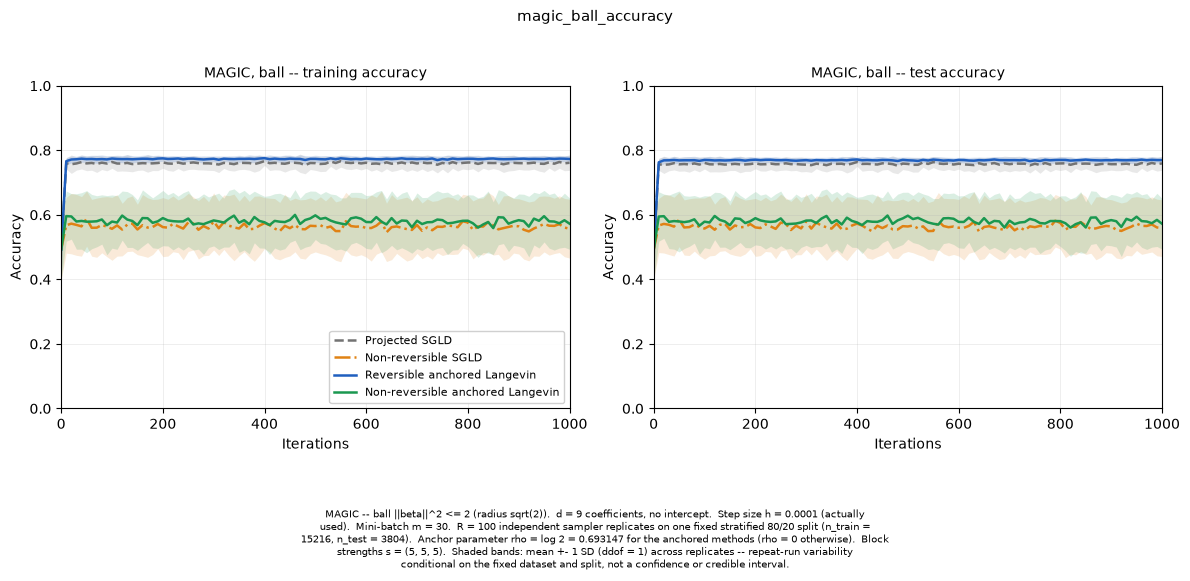

MAGIC -- ball ||beta||^2 <= 2 (radius sqrt(2)).  d = 9 coefficients, no intercept.  Step size h = 0.0001 (actually
used).  Mini-batch m = 30.  R = 100 independent sampler replicates on one fixed stratified 80/20 split (n_train =
15216, n_test = 3804).  Anchor parameter rho = log 2 = 0.693147 for the anchored methods (rho = 0 otherwise).  Block
strengths s = (5, 5, 5).  Shaded bands: mean +- 1 SD (ddof = 1) across replicates -- repeat-run variability
conditional on the fixed dataset and split, not a confidence or credible interval.
saved: /home/user/Accelerating-Non-Differentiable-sampling/figures/magic_ball_accuracy.png
       /home/user/Accelerating-Non-Differentiable-sampling/figures/magic_ball_accuracy.pdf



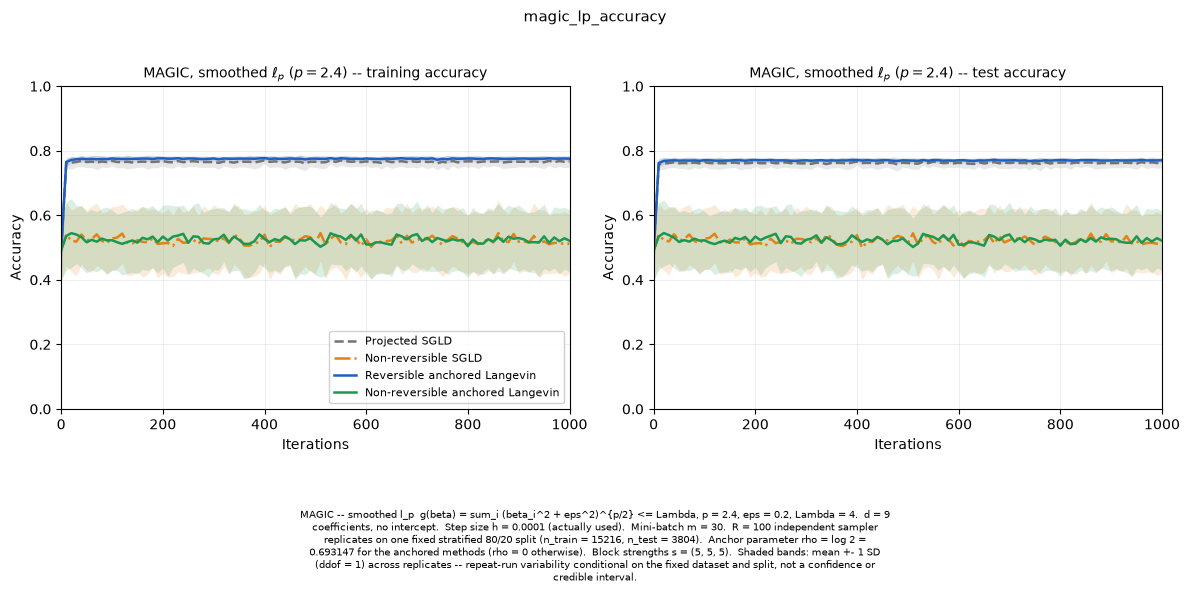

MAGIC -- smoothed l_p  g(beta) = sum_i (beta_i^2 + eps^2)^{p/2} <= Lambda, p = 2.4, eps = 0.2, Lambda = 4.  d = 9
coefficients, no intercept.  Step size h = 0.0001 (actually used).  Mini-batch m = 30.  R = 100 independent sampler
replicates on one fixed stratified 80/20 split (n_train = 15216, n_test = 3804).  Anchor parameter rho = log 2 =
0.693147 for the anchored methods (rho = 0 otherwise).  Block strengths s = (5, 5, 5).  Shaded bands: mean +- 1 SD
(ddof = 1) across replicates -- repeat-run variability conditional on the fixed dataset and split, not a confidence or
credible interval.
saved: /home/user/Accelerating-Non-Differentiable-sampling/figures/magic_lp_accuracy.png
       /home/user/Accelerating-Non-Differentiable-sampling/figures/magic_lp_accuracy.pdf



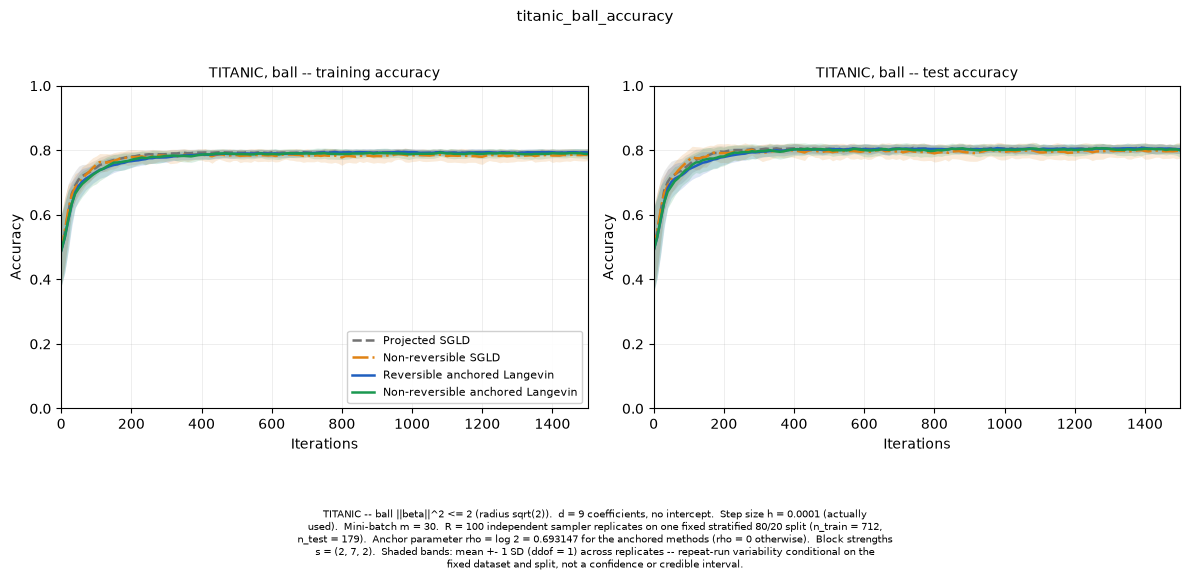

TITANIC -- ball ||beta||^2 <= 2 (radius sqrt(2)).  d = 9 coefficients, no intercept.  Step size h = 0.0001 (actually
used).  Mini-batch m = 30.  R = 100 independent sampler replicates on one fixed stratified 80/20 split (n_train = 712,
n_test = 179).  Anchor parameter rho = log 2 = 0.693147 for the anchored methods (rho = 0 otherwise).  Block strengths
s = (2, 7, 2).  Shaded bands: mean +- 1 SD (ddof = 1) across replicates -- repeat-run variability conditional on the
fixed dataset and split, not a confidence or credible interval.
saved: /home/user/Accelerating-Non-Differentiable-sampling/figures/titanic_ball_accuracy.png
       /home/user/Accelerating-Non-Differentiable-sampling/figures/titanic_ball_accuracy.pdf



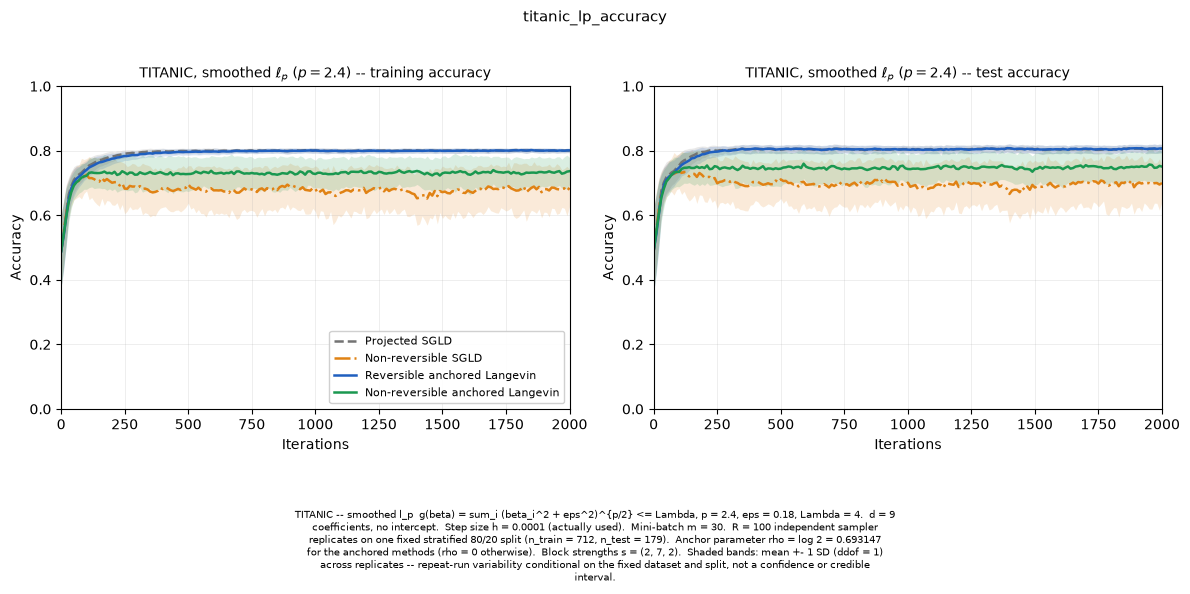

TITANIC -- smoothed l_p  g(beta) = sum_i (beta_i^2 + eps^2)^{p/2} <= Lambda, p = 2.4, eps = 0.18, Lambda = 4.  d = 9
coefficients, no intercept.  Step size h = 0.0001 (actually used).  Mini-batch m = 30.  R = 100 independent sampler
replicates on one fixed stratified 80/20 split (n_train = 712, n_test = 179).  Anchor parameter rho = log 2 = 0.693147
for the anchored methods (rho = 0 otherwise).  Block strengths s = (2, 7, 2).  Shaded bands: mean +- 1 SD (ddof = 1)
across replicates -- repeat-run variability conditional on the fixed dataset and split, not a confidence or credible
interval.
saved: /home/user/Accelerating-Non-Differentiable-sampling/figures/titanic_lp_accuracy.png
       /home/user/Accelerating-Non-Differentiable-sampling/figures/titanic_lp_accuracy.pdf



In [18]:
FIGURE_FILES: Dict[str, Tuple[str, str]] = {}
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        print(f"[{_spec.figure_name}] NOT PRODUCED -- {SKIPPED.get(_spec.key)}")
        continue
    _fig, _png, _pdf = make_figure(RESULTS[_spec.key], _spec.figure_name)
    FIGURE_FILES[_spec.figure_name] = (_png, _pdf)
    plt.show()
    print(_wrap(caption_for(RESULTS[_spec.key])))
    print(f"saved: {_png}\n       {_pdf}\n")

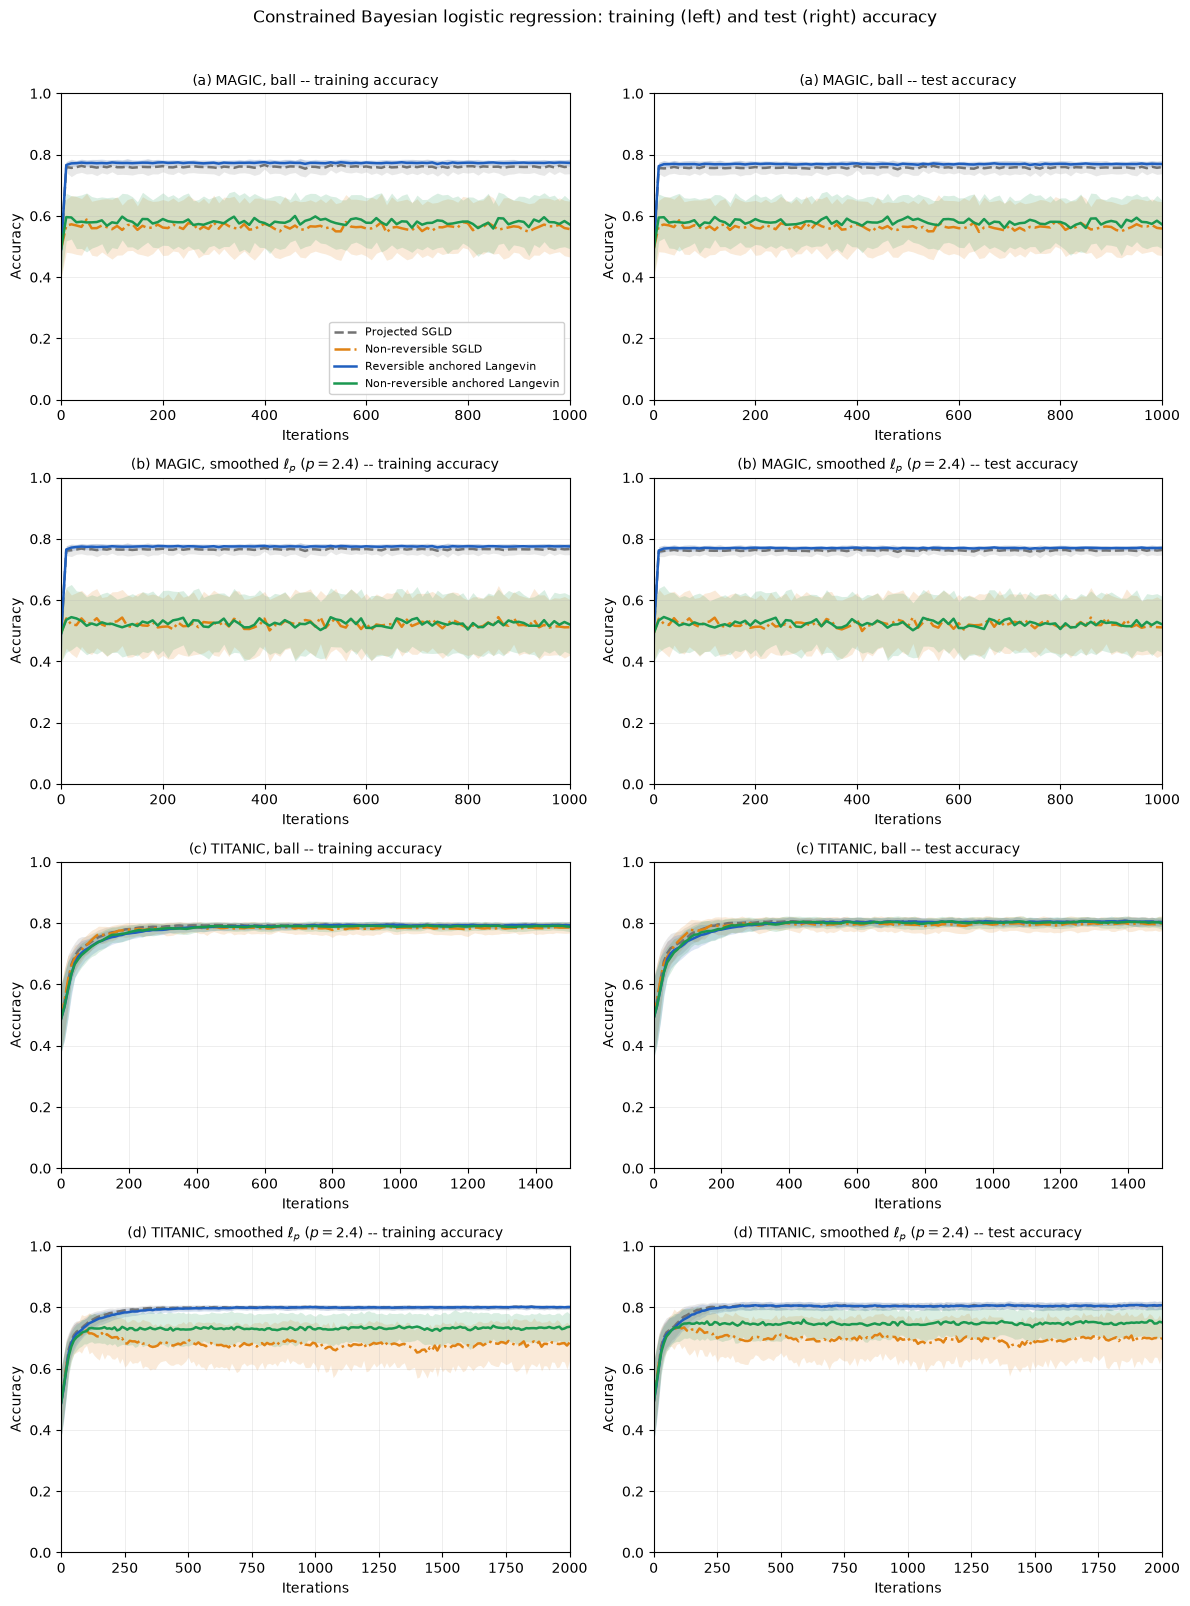

saved: /home/user/Accelerating-Non-Differentiable-sampling/figures/combined_accuracy.png
       /home/user/Accelerating-Non-Differentiable-sampling/figures/combined_accuracy.pdf


In [19]:
# Optional combined four-row, two-column figure.
_avail = [s for s in EXPERIMENTS if s.key in RESULTS]
if _avail:
    _fig, _axes = plt.subplots(len(_avail), 2, figsize=(12.0, 4.0 * len(_avail)), squeeze=False)
    for _i, _spec in enumerate(_avail):
        plot_accuracy_panels(RESULTS[_spec.key], _axes[_i], show_legend=(_i == 0),
                             title_prefix=f"({chr(97+_i)}) ")
    _fig.suptitle("Constrained Bayesian logistic regression: training (left) and test (right) accuracy",
                  fontsize=12, y=1.001)
    _fig.tight_layout(rect=(0, 0, 1, 0.99))
    _cpng = os.path.join(FIGURE_DIR, "combined_accuracy.png")
    _cpdf = os.path.join(FIGURE_DIR, "combined_accuracy.pdf")
    _fig.savefig(_cpng, dpi=300, bbox_inches="tight")
    _fig.savefig(_cpdf, bbox_inches="tight")
    FIGURE_FILES["combined_accuracy"] = (_cpng, _cpdf)
    plt.show()
    print(f"saved: {_cpng}\n       {_cpdf}")

### 11.1 (Separate) posterior-averaged predictions

The four required figures deliberately use the **current coefficient vector** at each
checkpoint. Posterior-averaged predictions are a *different* quantity and are therefore shown
**separately**, never substituted into the curves above. They average **probabilities**, not
coefficients:

$$\bar p_j=\frac{1}{|\mathcal C_{\rm post}|}\sum_{k\in\mathcal C_{\rm post}}\sigma(X_j^\top\beta_k),
\qquad \widehat y_j=\mathbf 1\{\bar p_j\ge\tfrac12\},$$

taken over the second half of the checkpoints of each individual run (a crude burn-in rule),
then summarised across replicates. This is a predictive summary, not evidence of convergence.

In [20]:
def posterior_averaged_accuracy(X: np.ndarray, y: np.ndarray, betas: np.ndarray,
                                burn_frac: float = 0.5) -> np.ndarray:
    """Average PROBABILITIES over the post-burn-in checkpoints of each run -> (R,) accuracy."""
    n_ck = betas.shape[0]
    start = int(np.floor(burn_frac * n_ck))
    acc_p = np.zeros((betas.shape[1], X.shape[0]))
    for i in range(start, n_ck):
        acc_p += sigmoid(betas[i] @ X.T)
    acc_p /= (n_ck - start)
    return np.mean((acc_p >= 0.5) == y.astype(bool)[None, :], axis=1)

In [21]:
_rows = []
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    _ds = DATASETS[_spec.dataset]
    for _mk in METHOD_KEYS:
        _b = RESULTS[_spec.key]["methods"][_mk]["betas"]
        _tr = posterior_averaged_accuracy(_ds.X_train, _ds.y_train, _b)
        _te = posterior_averaged_accuracy(_ds.X_test, _ds.y_test, _b)
        _last_te = RESULTS[_spec.key]["methods"][_mk]["acc_test"][-1]
        _rows.append(dict(experiment=_spec.key, method=METHOD_LABEL[_mk],
                          post_avg_acc_train=_tr.mean(), post_avg_acc_train_sd=_tr.std(ddof=1),
                          post_avg_acc_test=_te.mean(), post_avg_acc_test_sd=_te.std(ddof=1),
                          last_iterate_acc_test=_last_te.mean()))
POSTERIOR_AVG = pd.DataFrame(_rows)
print("Posterior-averaged predictions (probability averaging over the second half of each run's "
      "checkpoints) -- reported SEPARATELY from the required accuracy curves")
print(POSTERIOR_AVG.to_string(index=False, float_format=lambda v: f"{v:.4f}") if len(POSTERIOR_AVG)
      else "(no experiments ran)")
if len(POSTERIOR_AVG):
    POSTERIOR_AVG.to_csv(os.path.join(RESULTS_DIR, "posterior_averaged_accuracy.csv"), index=False)

Posterior-averaged predictions (probability averaging over the second half of each run's checkpoints) -- reported SEPARATELY from the required accuracy curves
  experiment                           method  post_avg_acc_train  post_avg_acc_train_sd  post_avg_acc_test  post_avg_acc_test_sd  last_iterate_acc_test
  magic_ball                   Projected SGLD              0.7805                 0.0012             0.7760                0.0020                 0.7592
  magic_ball              Non-reversible SGLD              0.7174                 0.0366             0.7169                0.0349                 0.5586
  magic_ball     Reversible anchored Langevin              0.7807                 0.0008             0.7760                0.0018                 0.7695
  magic_ball Non-reversible anchored Langevin              0.7460                 0.0165             0.7468                0.0140                 0.5724
    magic_lp                   Projected SGLD              0.7815           

---
## 12. Step-size sensitivity and numerical checks

$h=10^{-4}$ is the source's **reported candidate**, not a verified accurate step. Two features
of this problem make it suspect, especially for MAGIC: the potential is the **sum** over
$n_{\rm train}=15216$ training rows (so $\|\nabla U\|$ is $O(10^3)$--$O(10^4)$), and the
non-reversible drift multiplies that by $\|J\|=O(s\|\beta\|)$ with $s=5$.

We therefore rerun each experiment at $h$, $h/2$ and $h/4$ with $1\times$, $2\times$ and
$4\times$ the iteration count, so the **simulated time $t=kh$ is identical** across levels, and
we compare on the $t$ axis: accuracy, coefficient moments, the full training loss $U$, and
geometry observables ($H_K$, $\|\beta\|^2$, the anchor $a$). We also expose batch-size and
full-gradient comparisons.

**Sensitivity repeat count: `SENSITIVITY_REPLICATES` (default 20), disclosed here and stored
in the saved configuration.** The step is held **common across methods** within each comparison.
Projection rates and numerical failures are reported. *Bounded projected states are not, on
their own, evidence of numerical accuracy*: the projection guarantees boundedness regardless of
how badly the underlying discretisation is behaving.

Nothing here normalises the likelihood, alters the constraint, clips gradients, rescales $J$,
or is tuned against test accuracy.

In [22]:
def step_size_scale_audit(spec: ExperimentSpec, datasets: Dict[str, Dataset],
                          h: float = H_REPORTED, n_pts: int = 400,
                          seed: int = 99) -> Dict[str, float]:
    """How big is one deterministic step compared with the constraint set itself?

    Reports median ||h a grad U_0||, median ||h a (I + J) grad U_0|| and the typical Gaussian
    increment, against the diameter of K.  A drift step comparable to (or larger than) the set is
    a direct sign that h is too large for this potential -- independently of whether the
    projection keeps the iterates bounded.
    """
    ds = datasets[spec.dataset]
    geom = make_geometry(spec)
    rng = np.random.default_rng(seed)
    B = sample_unit_ball(rng, n_pts)
    out: Dict[str, float] = {}
    for tag, rho in (("rho=0", 0.0), ("rho=log2", RHO_ANCHORED)):
        G = grad_U0_full(B, ds.X_train, ds.y_train, geom, rho)
        a = anchor_coefficient(B, geom, rho)
        d_rev = h * a[:, None] * G
        d_non = h * a[:, None] * (G + apply_J(B, G, geom, spec.block_scales))
        out[f"median_drift_alpha0[{tag}]"] = float(np.median(np.linalg.norm(d_rev, axis=1)))
        out[f"median_drift_alpha1[{tag}]"] = float(np.median(np.linalg.norm(d_non, axis=1)))
    out["median_noise_step"] = float(np.median(np.sqrt(2.0 * h * anchor_coefficient(B, geom, 0.0))
                                               * math.sqrt(DIM)))
    if isinstance(geom, BallGeometry):
        out["set_diameter"] = 2.0 * geom.radius
    else:
        out["set_diameter"] = 2.0 * float(np.max(np.linalg.norm(geom.to_boundary(B), axis=1)))
    out["median_grad_U_norm"] = float(np.median(np.linalg.norm(
        grad_U_full(B, ds.X_train, ds.y_train), axis=1)))
    return out


def run_step_size_sensitivity(spec: ExperimentSpec, datasets: Dict[str, Dataset],
                              levels: Sequence[int] = (1, 2, 4),
                              n_replicates: int = SENSITIVITY_REPLICATES,
                              h_base: float = H_REPORTED,
                              verbose: bool = True) -> Dict[str, object]:
    """Refine h by 1/r while multiplying iterations by r, holding simulated time t = k h fixed."""
    out: Dict[str, object] = dict(spec=spec.key, levels=list(levels), h_base=float(h_base),
                                  n_replicates=int(n_replicates), by_level={})
    for r in levels:
        res = run_experiment(spec, datasets, h=h_base / r, n_iter=spec.n_iter * r,
                             n_replicates=n_replicates,
                             checkpoint_every=CHECKPOINT_EVERY * r,
                             stream_tag=f"sens_r{r}", verbose=False)
        res["sim_time"] = np.asarray(res["methods"]["psgld"]["checkpoints"], dtype=float) * (h_base / r)
        out["by_level"][r] = res
        if verbose:
            print(f"  h = h/{r} = {h_base/r:.3e}, n_iter = {spec.n_iter*r}")
            for mk in METHOD_KEYS:
                md = res["methods"][mk]
                print(f"      {METHOD_LABEL[mk]:36s} acc_tr={md['acc_train'][-1].mean():.4f} "
                      f"acc_te={md['acc_test'][-1].mean():.4f} "
                      f"|beta|={np.linalg.norm(md['betas'][-1], axis=1).mean():.4f} "
                      f"U={md['train_loss'][-1].mean():.2f} "
                      f"proj={md['projection_rate']:.3f} nonfinite={md['n_nonfinite']}")
    return out


def sensitivity_table(sens: Dict[str, object]) -> pd.DataFrame:
    rows = []
    for r, res in sens["by_level"].items():
        for mk in METHOD_KEYS:
            md = res["methods"][mk]
            b = md["betas"][-1]
            rows.append(dict(
                level=f"h/{r}", h=res["h"], n_iter=res["n_iter"],
                sim_time=float(res["sim_time"][-1]), method=METHOD_LABEL[mk],
                acc_train=float(md["acc_train"][-1].mean()),
                acc_test=float(md["acc_test"][-1].mean()),
                mean_norm_beta=float(np.linalg.norm(b, axis=1).mean()),
                mean_beta1=float(b[:, 0].mean()), sd_beta1=float(b[:, 0].std(ddof=1)),
                mean_coord_sd=float(b.std(axis=0, ddof=1).mean()),
                train_loss_U=float(md["train_loss"][-1].mean()),
                mean_H=float(md["geometry_obs"]["H"][-1].mean()),
                mean_anchor_a=float(md["geometry_obs"]["anchor_a"][-1].mean()),
                projection_rate=float(md["projection_rate"]),
                n_nonfinite=int(md["n_nonfinite"]),
            ))
    return pd.DataFrame(rows)


def run_batch_size_comparison(spec: ExperimentSpec, datasets: Dict[str, Dataset],
                              batch_sizes: Sequence[int] = (30, 120),
                              include_full_gradient: bool = True,
                              n_replicates: int = SENSITIVITY_REPLICATES) -> pd.DataFrame:
    rows = []
    configs: List[Tuple[str, dict]] = [(f"m={m}", dict(m=m, full_gradient=False)) for m in batch_sizes]
    if include_full_gradient:
        configs.append(("full gradient", dict(m=BATCH_SIZE, full_gradient=True)))
    for tag, kw in configs:
        res = run_experiment(spec, datasets, n_replicates=n_replicates,
                             stream_tag=f"batch_{tag}", verbose=False, **kw)
        for mk in METHOD_KEYS:
            md = res["methods"][mk]
            rows.append(dict(gradient=tag, method=METHOD_LABEL[mk],
                             acc_train=float(md["acc_train"][-1].mean()),
                             acc_test=float(md["acc_test"][-1].mean()),
                             sd_acc_test=float(md["acc_test"][-1].std(ddof=1)),
                             train_loss_U=float(md["train_loss"][-1].mean()),
                             mean_norm_beta=float(np.linalg.norm(md["betas"][-1], axis=1).mean()),
                             projection_rate=float(md["projection_rate"]),
                             n_nonfinite=int(md["n_nonfinite"])))
    return pd.DataFrame(rows)


def plot_sensitivity(sens: Dict[str, object], spec_key: str, outdir: str = FIGURE_DIR):
    """Accuracy, ||beta||, U and H against simulated time t = k h, one column per level."""
    fig, axes = plt.subplots(2, 2, figsize=(12.0, 7.4))
    panels = [("acc_test", "Test accuracy"), ("norm", r"mean $\|\beta\|$"),
              ("loss", "mean full training loss $U$"), ("H", r"mean $H_K(\beta)$")]
    lvl_style = {1: "-", 2: "--", 4: ":"}
    for ax, (what, ylab) in zip(axes.ravel(), panels):
        for r, res in sens["by_level"].items():
            t = res["sim_time"]
            for mk in METHOD_KEYS:
                md = res["methods"][mk]
                if what == "acc_test":
                    yv = md["acc_test"].mean(axis=1)
                elif what == "norm":
                    yv = np.linalg.norm(md["betas"], axis=2).mean(axis=1)
                elif what == "loss":
                    yv = md["train_loss"].mean(axis=1)
                else:
                    yv = md["geometry_obs"]["H"].mean(axis=1)
                ax.plot(t, yv, color=STYLE[mk]["color"], linestyle=lvl_style.get(r, "-"),
                        linewidth=1.4, alpha=0.95,
                        label=f"{METHOD_LABEL[mk]} (h/{r})" if what == "acc_test" else None)
        ax.set_xlabel(r"simulated time $t = k h$")
        ax.set_ylabel(ylab)
        ax.grid(True, alpha=0.25, linewidth=0.6)
    axes[0, 0].set_ylim(0.0, 1.0)
    axes[0, 0].legend(fontsize=6.3, ncol=2, loc="lower right", framealpha=0.9)
    fig.suptitle(f"Step-size sensitivity: {spec_key}  "
                 f"(h, h/2, h/4 with 1x, 2x, 4x iterations; R = {sens['n_replicates']})", fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    png = os.path.join(outdir, f"sensitivity_{spec_key}.png")
    pdf = os.path.join(outdir, f"sensitivity_{spec_key}.pdf")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    return fig, png, pdf

In [23]:
print("=" * 78)
print("12.0  Step-size scale audit: one drift step vs the size of K")
print("=" * 78)
STEP_AUDIT = {}
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    STEP_AUDIT[_spec.key] = step_size_scale_audit(_spec, DATASETS)
print(pd.DataFrame(STEP_AUDIT).T.to_string(float_format=lambda v: f"{v:.4g}"))
print("\nA median drift step of the same order as `set_diameter` means h = 1e-4 is NOT a small "
      "step for that experiment: the deterministic move alone crosses the constraint set.")

12.0  Step-size scale audit: one drift step vs the size of K


              median_drift_alpha0[rho=0]  median_drift_alpha1[rho=0]  median_drift_alpha0[rho=log2]  median_drift_alpha1[rho=log2]  median_noise_step  set_diameter  median_grad_U_norm
magic_ball                        0.6125                       1.203                         0.4643                         0.9042            0.04243         2.828                6125
magic_lp                          0.6125                       1.862                         0.5464                          1.655            0.04243         4.067                6125
titanic_ball                     0.01984                     0.03587                        0.01475                        0.02705            0.04243         2.828               198.4
titanic_lp                       0.01984                     0.05484                        0.01752                         0.0491            0.04243         4.099               198.4

A median drift step of the same order as `set_diameter` means h = 1e-4 is NOT a

Step-size sensitivity with SENSITIVITY_REPLICATES = 20 (disclosed; this is smaller than the R = 100 used for the main figures).

[magic_ball]


  h = h/1 = 1.000e-04, n_iter = 1000
      Projected SGLD                       acc_tr=0.7673 acc_te=0.7647 |beta|=1.4002 U=7875.87 proj=0.790 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.5652 acc_te=0.5668 |beta|=1.3908 U=13078.45 proj=0.986 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7766 acc_te=0.7721 |beta|=1.4030 U=7689.29 proj=0.724 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.5606 acc_te=0.5613 |beta|=1.4142 U=13741.82 proj=0.968 nonfinite=0


  h = h/2 = 5.000e-05, n_iter = 2000
      Projected SGLD                       acc_tr=0.7719 acc_te=0.7696 |beta|=1.3901 U=7700.88 proj=0.719 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.5742 acc_te=0.5754 |beta|=1.4132 U=12947.38 proj=0.965 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7771 acc_te=0.7735 |beta|=1.3983 U=7622.22 proj=0.676 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.5944 acc_te=0.5944 |beta|=1.4133 U=12187.74 proj=0.949 nonfinite=0


  h = h/4 = 2.500e-05, n_iter = 4000
      Projected SGLD                       acc_tr=0.7754 acc_te=0.7706 |beta|=1.3999 U=7646.15 proj=0.672 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.6334 acc_te=0.6312 |beta|=1.4131 U=11139.13 proj=0.947 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7792 acc_te=0.7734 |beta|=1.4057 U=7591.08 proj=0.634 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7133 acc_te=0.7079 |beta|=1.4135 U=8979.55 proj=0.901 nonfinite=0


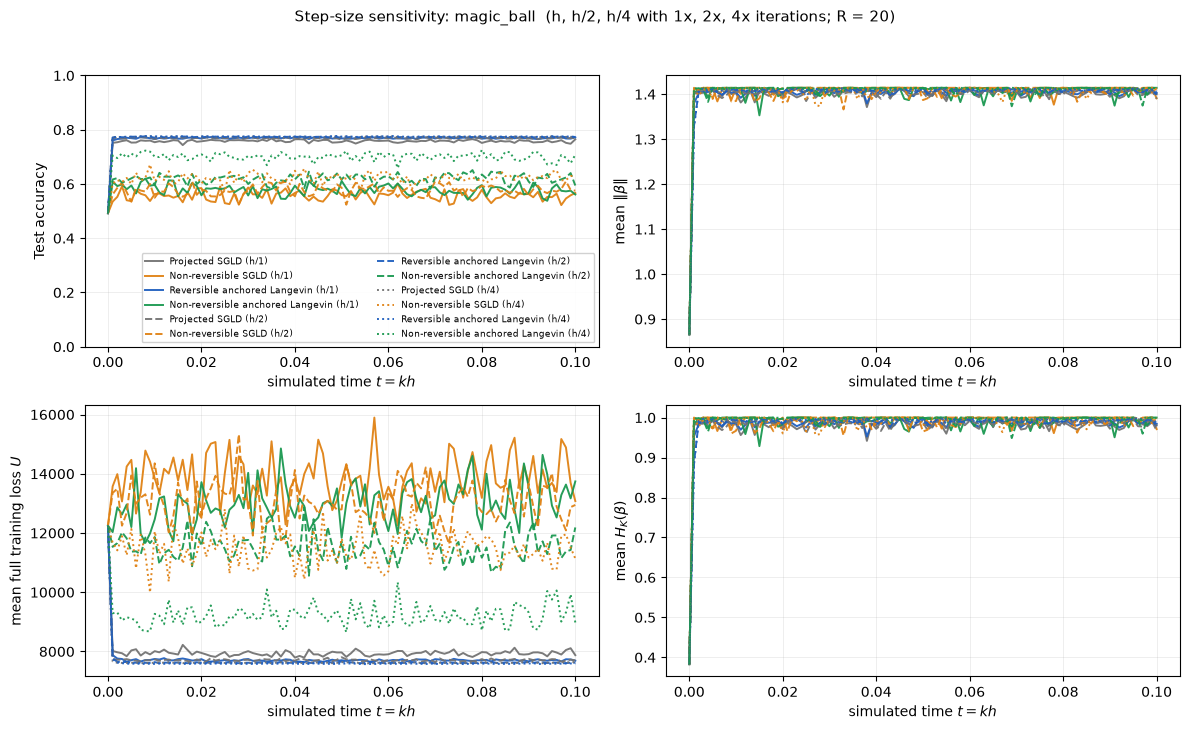

level       h  n_iter  sim_time                           method  acc_train  acc_test  mean_norm_beta  mean_beta1  sd_beta1  mean_coord_sd  train_loss_U   mean_H  mean_anchor_a  projection_rate  n_nonfinite
  h/1  0.0001    1000       0.1                   Projected SGLD   0.767271  0.764682         1.40018   -0.270306  0.188407       0.131737       7875.87 0.980889              1          0.78955            0
  h/1  0.0001    1000       0.1              Non-reversible SGLD   0.565152  0.566798         1.39079   -0.330317  0.674786       0.305568       13078.4 0.971061              1          0.98605            0
  h/1  0.0001    1000       0.1     Reversible anchored Langevin   0.776594  0.772082         1.40303   -0.289214  0.124374      0.0914264       7689.29 0.984471       0.505519          0.72405            0
  h/1  0.0001    1000       0.1 Non-reversible anchored Langevin    0.56065  0.561304         1.41421   -0.179251   0.78203       0.285392       13741.8        1           

  h = h/1 = 1.000e-04, n_iter = 1000
      Projected SGLD                       acc_tr=0.7725 acc_te=0.7673 |beta|=1.8964 U=7697.33 proj=0.430 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.5230 acc_te=0.5208 |beta|=1.8323 U=17965.29 proj=0.996 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7782 acc_te=0.7719 |beta|=1.9219 U=7525.80 proj=0.328 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.5002 acc_te=0.5001 |beta|=1.8465 U=20116.36 proj=0.992 nonfinite=0


  h = h/2 = 5.000e-05, n_iter = 2000
      Projected SGLD                       acc_tr=0.7742 acc_te=0.7711 |beta|=1.8943 U=7532.91 proj=0.315 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.5459 acc_te=0.5466 |beta|=1.8443 U=16810.49 proj=0.991 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7784 acc_te=0.7735 |beta|=1.9205 U=7452.61 proj=0.257 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.4820 acc_te=0.4824 |beta|=1.8428 U=18945.21 proj=0.984 nonfinite=0


  h = h/4 = 2.500e-05, n_iter = 4000
      Projected SGLD                       acc_tr=0.7767 acc_te=0.7706 |beta|=1.9202 U=7477.26 proj=0.245 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.5138 acc_te=0.5164 |beta|=1.8238 U=17380.75 proj=0.984 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7796 acc_te=0.7734 |beta|=1.9336 U=7424.68 proj=0.200 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.5283 acc_te=0.5297 |beta|=1.8237 U=16674.35 proj=0.971 nonfinite=0


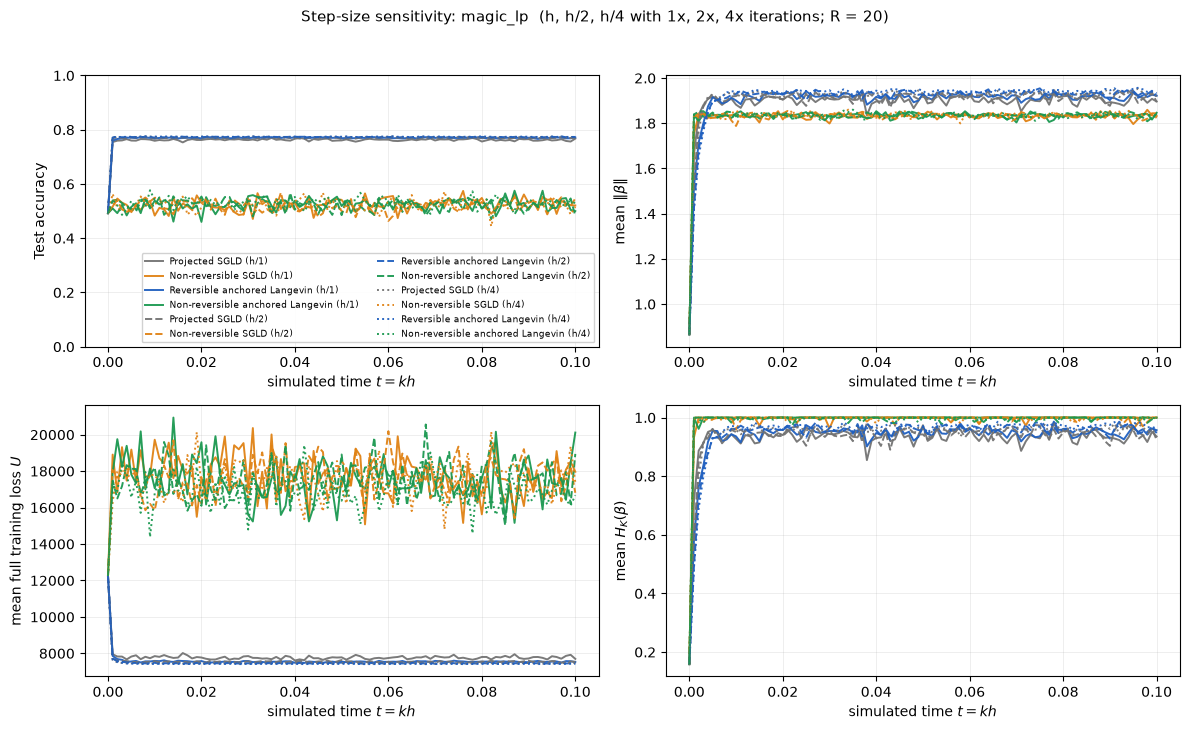

level       h  n_iter  sim_time                           method  acc_train  acc_test  mean_norm_beta  mean_beta1  sd_beta1  mean_coord_sd  train_loss_U   mean_H  mean_anchor_a  projection_rate  n_nonfinite
  h/1  0.0001    1000       0.1                   Projected SGLD   0.772516  0.767337         1.89643   -0.382669  0.202559       0.158804       7697.33 0.935499              1          0.42955            0
  h/1  0.0001    1000       0.1              Non-reversible SGLD   0.523048   0.52082         1.83227   0.0208156   1.05745       0.376569       17965.3        1              1           0.9956            0
  h/1  0.0001    1000       0.1     Reversible anchored Langevin   0.778158  0.771872         1.92189   -0.397348  0.136337       0.111676        7525.8 0.956965       0.515424          0.32825            0
  h/1  0.0001    1000       0.1 Non-reversible anchored Langevin   0.500187  0.500092         1.84652    0.312381   1.18803       0.378747       20116.4        1           

  h = h/1 = 1.000e-04, n_iter = 1500
      Projected SGLD                       acc_tr=0.7900 acc_te=0.8008 |beta|=1.4062 U=364.20 proj=0.370 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.7791 acc_te=0.7964 |beta|=1.4073 U=368.24 proj=0.411 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7902 acc_te=0.8036 |beta|=1.4055 U=363.92 proj=0.258 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7895 acc_te=0.8050 |beta|=1.4056 U=366.01 proj=0.280 nonfinite=0


  h = h/2 = 5.000e-05, n_iter = 3000
      Projected SGLD                       acc_tr=0.7975 acc_te=0.8042 |beta|=1.4014 U=364.39 proj=0.276 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.7919 acc_te=0.7972 |beta|=1.4033 U=365.94 proj=0.291 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7967 acc_te=0.8047 |beta|=1.4007 U=364.50 proj=0.189 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7919 acc_te=0.8014 |beta|=1.3990 U=365.32 proj=0.196 nonfinite=0


  h = h/4 = 2.500e-05, n_iter = 6000
      Projected SGLD                       acc_tr=0.7917 acc_te=0.8014 |beta|=1.3915 U=364.67 proj=0.211 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.7941 acc_te=0.8036 |beta|=1.3934 U=365.40 proj=0.216 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7920 acc_te=0.8008 |beta|=1.3916 U=364.90 proj=0.147 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7912 acc_te=0.8020 |beta|=1.3929 U=365.88 proj=0.150 nonfinite=0


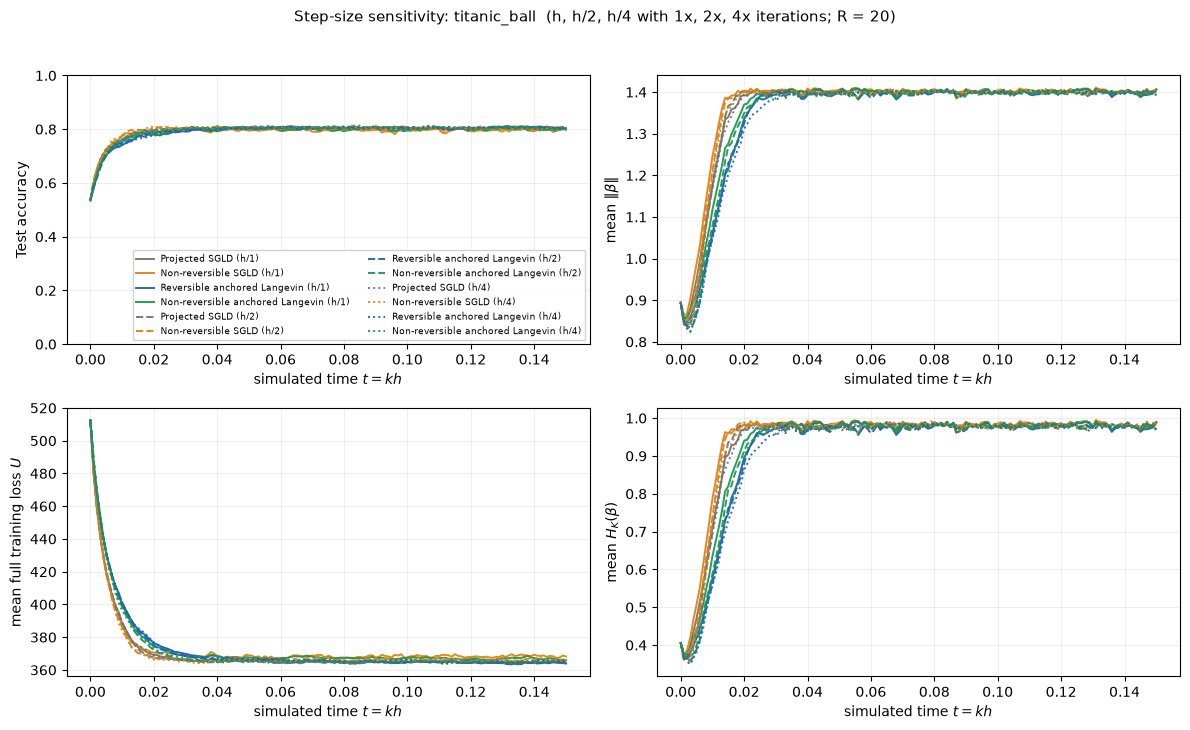

level       h  n_iter  sim_time                           method  acc_train  acc_test  mean_norm_beta  mean_beta1  sd_beta1  mean_coord_sd  train_loss_U   mean_H  mean_anchor_a  projection_rate  n_nonfinite
  h/1  0.0001    1500      0.15                   Projected SGLD   0.790028  0.800838         1.40619   -0.216764  0.065422      0.0891945       364.204 0.988832              1         0.370367            0
  h/1  0.0001    1500      0.15              Non-reversible SGLD   0.779073  0.796369         1.40729   -0.207249 0.0684691       0.122872       368.243 0.990374              1         0.411167            0
  h/1  0.0001    1500      0.15     Reversible anchored Langevin   0.790239  0.803631         1.40548   -0.225851 0.0629658      0.0876818       363.916 0.987817       0.504302           0.2584            0
  h/1  0.0001    1500      0.15 Non-reversible anchored Langevin   0.789466  0.805028         1.40557   -0.221895 0.0621389       0.109422       366.012 0.987925       0.50

  h = h/1 = 1.000e-04, n_iter = 2000
      Projected SGLD                       acc_tr=0.8013 acc_te=0.8056 |beta|=1.8958 U=345.45 proj=0.242 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.6930 acc_te=0.7249 |beta|=1.8752 U=442.98 proj=0.738 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.8016 acc_te=0.8061 |beta|=1.8972 U=345.13 proj=0.165 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7369 acc_te=0.7628 |beta|=1.9057 U=389.58 proj=0.416 nonfinite=0


  h = h/2 = 5.000e-05, n_iter = 4000
      Projected SGLD                       acc_tr=0.8025 acc_te=0.7975 |beta|=1.8998 U=345.40 proj=0.176 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.7164 acc_te=0.7402 |beta|=1.8937 U=406.94 proj=0.414 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.8023 acc_te=0.7958 |beta|=1.9002 U=345.52 proj=0.117 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7668 acc_te=0.7788 |beta|=1.9321 U=366.67 proj=0.179 nonfinite=0


  h = h/4 = 2.500e-05, n_iter = 8000
      Projected SGLD                       acc_tr=0.7989 acc_te=0.8050 |beta|=1.8874 U=345.48 proj=0.134 nonfinite=0
      Non-reversible SGLD                  acc_tr=0.7778 acc_te=0.7916 |beta|=1.9158 U=357.39 proj=0.193 nonfinite=0
      Reversible anchored Langevin         acc_tr=0.7987 acc_te=0.8034 |beta|=1.8874 U=345.48 proj=0.091 nonfinite=0
      Non-reversible anchored Langevin     acc_tr=0.7942 acc_te=0.8036 |beta|=1.9007 U=349.00 proj=0.108 nonfinite=0


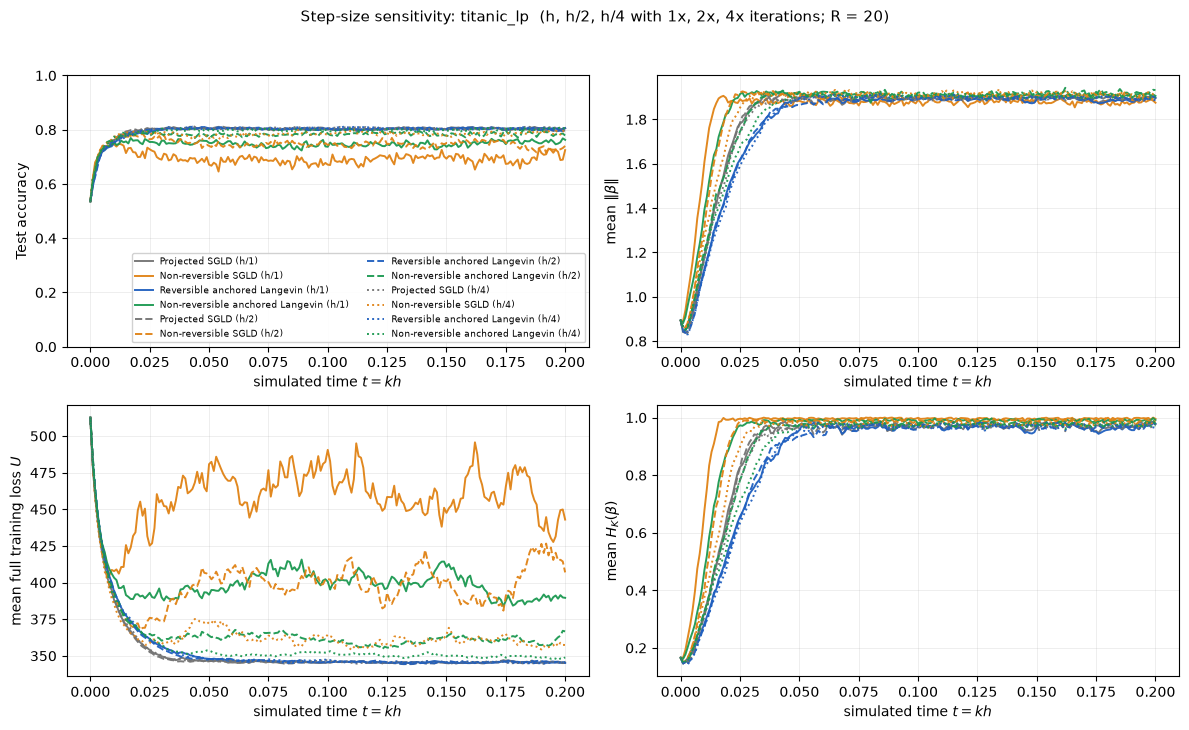

level       h  n_iter  sim_time                           method  acc_train  acc_test  mean_norm_beta  mean_beta1  sd_beta1  mean_coord_sd  train_loss_U   mean_H  mean_anchor_a  projection_rate  n_nonfinite
  h/1  0.0001    2000       0.2                   Projected SGLD   0.801334  0.805587         1.89575   -0.278542 0.0994619       0.117911       345.452 0.976821              1         0.241875            0
  h/1  0.0001    2000       0.2              Non-reversible SGLD   0.693048   0.72486         1.87518   -0.136465 0.0769263       0.362297       442.981 0.995389              1           0.7378            0
  h/1  0.0001    2000       0.2     Reversible anchored Langevin   0.801615  0.806145         1.89725   -0.277904 0.0897934        0.11246       345.126 0.978617       0.507538          0.16545            0
  h/1  0.0001    2000       0.2 Non-reversible anchored Langevin   0.736938  0.762849         1.90568   -0.214398  0.102202       0.279135        389.58  0.99134       0.50

In [24]:
SENSITIVITY: Dict[str, object] = {}
SENS_TABLES: Dict[str, pd.DataFrame] = {}
print(f"Step-size sensitivity with SENSITIVITY_REPLICATES = {SENSITIVITY_REPLICATES} "
      f"(disclosed; this is smaller than the R = {N_REPLICATES} used for the main figures).")
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    print(f"\n[{_spec.key}]")
    SENSITIVITY[_spec.key] = run_step_size_sensitivity(_spec, DATASETS)
    SENS_TABLES[_spec.key] = sensitivity_table(SENSITIVITY[_spec.key])
    _f, _p1, _p2 = plot_sensitivity(SENSITIVITY[_spec.key], _spec.key)
    FIGURE_FILES[f"sensitivity_{_spec.key}"] = (_p1, _p2)
    plt.show()
    print(SENS_TABLES[_spec.key].to_string(index=False, float_format=lambda v: f"{v:.6g}"))

In [25]:
BATCH_TABLES: Dict[str, pd.DataFrame] = {}
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    BATCH_TABLES[_spec.key] = run_batch_size_comparison(_spec, DATASETS)
    print(f"\n[{_spec.key}] mini-batch / full-gradient comparison (R = {SENSITIVITY_REPLICATES}, h = {H_REPORTED:g})")
    print(BATCH_TABLES[_spec.key].to_string(index=False, float_format=lambda v: f"{v:.4f}"))


[magic_ball] mini-batch / full-gradient comparison (R = 20, h = 0.0001)
     gradient                           method  acc_train  acc_test  sd_acc_test  train_loss_U  mean_norm_beta  projection_rate  n_nonfinite
         m=30                   Projected SGLD     0.7577    0.7554       0.0196     7956.0943          1.4105           0.7868            0
         m=30              Non-reversible SGLD     0.5826    0.5787       0.0893    12804.3967          1.4142           0.9856            0
         m=30     Reversible anchored Langevin     0.7749    0.7706       0.0079     7671.4790          1.4098           0.7199            0
         m=30 Non-reversible anchored Langevin     0.5936    0.5926       0.0682    12829.0227          1.4142           0.9695            0
        m=120                   Projected SGLD     0.7768    0.7705       0.0085     7638.0224          1.4142           0.9006            0
        m=120              Non-reversible SGLD     0.5646    0.5639       0.0532 


[magic_lp] mini-batch / full-gradient comparison (R = 20, h = 0.0001)
     gradient                           method  acc_train  acc_test  sd_acc_test  train_loss_U  mean_norm_beta  projection_rate  n_nonfinite
         m=30                   Projected SGLD     0.7655    0.7616       0.0148     7757.3263          1.9205           0.4268            0
         m=30              Non-reversible SGLD     0.5056    0.5069       0.1028    18455.6804          1.8348           0.9963            0
         m=30     Reversible anchored Langevin     0.7772    0.7706       0.0058     7507.9679          1.9214           0.3205            0
         m=30 Non-reversible anchored Langevin     0.5162    0.5157       0.1025    18505.8283          1.8341           0.9912            0
        m=120                   Projected SGLD     0.7781    0.7709       0.0062     7475.9945          1.9289           0.4140            0
        m=120              Non-reversible SGLD     0.5295    0.5324       0.0705   


[titanic_ball] mini-batch / full-gradient comparison (R = 20, h = 0.0001)
     gradient                           method  acc_train  acc_test  sd_acc_test  train_loss_U  mean_norm_beta  projection_rate  n_nonfinite
         m=30                   Projected SGLD     0.7952    0.8045       0.0143      364.7243          1.3999           0.3727            0
         m=30              Non-reversible SGLD     0.7851    0.7978       0.0246      368.4458          1.3995           0.3994            0
         m=30     Reversible anchored Langevin     0.7959    0.8045       0.0113      364.8259          1.4000           0.2634            0
         m=30 Non-reversible anchored Langevin     0.7864    0.7983       0.0220      366.2925          1.4006           0.2761            0
        m=120                   Projected SGLD     0.7940    0.7989       0.0132      365.6941          1.3941           0.3852            0
        m=120              Non-reversible SGLD     0.7855    0.7941       0.018


[titanic_lp] mini-batch / full-gradient comparison (R = 20, h = 0.0001)
     gradient                           method  acc_train  acc_test  sd_acc_test  train_loss_U  mean_norm_beta  projection_rate  n_nonfinite
         m=30                   Projected SGLD     0.8006    0.8045       0.0094      345.0488          1.8989           0.2486            0
         m=30              Non-reversible SGLD     0.7064    0.7268       0.0571      436.4280          1.8625           0.7365            0
         m=30     Reversible anchored Langevin     0.8001    0.8050       0.0123      345.2237          1.8970           0.1712            0
         m=30 Non-reversible anchored Langevin     0.7369    0.7609       0.0363      390.6701          1.9083           0.4337            0
        m=120                   Projected SGLD     0.7995    0.8084       0.0109      345.3418          1.8926           0.2628            0
        m=120              Non-reversible SGLD     0.6827    0.7014       0.0609 

In [26]:
print("=" * 78)
print("Numerical health summary for the main experiments")
print("=" * 78)
_rows = []
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    _r = RESULTS[_spec.key]
    for _mk in METHOD_KEYS:
        _md = _r["methods"][_mk]
        _rows.append(dict(experiment=_spec.key, method=METHOD_LABEL[_mk],
                          projection_rate=_md["projection_rate"],
                          n_nonfinite=_md["n_nonfinite"],
                          mean_drift_step=float(np.nanmean(_md["drift_norm"])),
                          mean_noise_step=float(np.nanmean(_md["noise_norm"])),
                          drift_over_noise=float(np.nanmean(_md["drift_norm"]) /
                                                 max(np.nanmean(_md["noise_norm"]), 1e-300)),
                          runtime_sec=_md["runtime_sec"]))
HEALTH = pd.DataFrame(_rows)
print(HEALTH.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("\nA projection rate near 1 means the chain is pinned to the boundary at essentially every "
      "step: the iterates stay bounded by construction, which is NOT evidence that the "
      "discretisation is accurate.")

Numerical health summary for the main experiments
  experiment                           method  projection_rate  n_nonfinite  mean_drift_step  mean_noise_step  drift_over_noise  runtime_sec
  magic_ball                   Projected SGLD           0.7855            0           0.3754           0.0413            9.0858       0.2739
  magic_ball              Non-reversible SGLD           0.9851            0           4.0211           0.0413           97.3230       0.3177
  magic_ball     Reversible anchored Langevin           0.7195            0           0.1701           0.0294            5.7797       0.2414
  magic_ball Non-reversible anchored Langevin           0.9705            0           2.0423           0.0293           69.6069       0.3219
    magic_lp                   Projected SGLD           0.4238            0           0.3611           0.0413            8.7403       2.3777
    magic_lp              Non-reversible SGLD           0.9956            0          14.8359           0

---
## 13. Saved artefacts, regeneration, and interpretation

### 13.1 Persist everything needed to regenerate the figures

In [27]:
def save_results(results: Dict[str, Dict[str, object]], datasets: Dict[str, Dataset],
                 outdir: str = RESULTS_DIR) -> Dict[str, str]:
    """Write per-run accuracies, coefficient checkpoints, summaries and diagnostics to .npz."""
    paths: Dict[str, str] = {}
    for key, res in results.items():
        arrs: Dict[str, np.ndarray] = {}
        for mk in METHOD_KEYS:
            md = res["methods"][mk]
            arrs[f"{mk}/checkpoints"] = np.asarray(md["checkpoints"])
            arrs[f"{mk}/acc_train"] = md["acc_train"]            # (n_ck, R) per-run accuracies
            arrs[f"{mk}/acc_test"] = md["acc_test"]
            arrs[f"{mk}/betas"] = md["betas"]                    # (n_ck, R, 9) coefficient checkpoints
            arrs[f"{mk}/train_loss"] = md["train_loss"]
            arrs[f"{mk}/drift_norm"] = md["drift_norm"]
            arrs[f"{mk}/noise_norm"] = md["noise_norm"]
            arrs[f"{mk}/projection_per_iter"] = np.asarray(res["methods"][mk].get("projection_per_iter", []))
            for on, ov in md["geometry_obs"].items():
                arrs[f"{mk}/obs_{on}"] = ov
            mu_tr, sd_tr = mean_sd(md["acc_train"], axis=1)
            mu_te, sd_te = mean_sd(md["acc_test"], axis=1)
            arrs[f"{mk}/acc_train_mean"] = mu_tr
            arrs[f"{mk}/acc_train_sd"] = sd_tr
            arrs[f"{mk}/acc_test_mean"] = mu_te
            arrs[f"{mk}/acc_test_sd"] = sd_te
        p = os.path.join(outdir, f"{key}_results.npz")
        np.savez_compressed(p, **arrs)
        paths[key] = p
    for name, ds in datasets.items():
        p = os.path.join(outdir, f"{name}_split.npz")
        np.savez_compressed(p, train_idx=ds.train_idx, test_idx=ds.test_idx,
                            y_train=ds.y_train, y_test=ds.y_test)
        paths[f"{name}_split"] = p
    return paths


def build_run_config(results, datasets, load_errors, skipped, checks, extra_metrics,
                     sens_tables, batch_tables, health, figure_files) -> dict:
    return dict(
        mode="quick" if QUICK else "full",
        quick_mode_warning=("QUICK MODE OUTPUT -- 5 replicates / 200 iterations. "
                            "This is a smoke test, NOT the full experiment.") if QUICK else None,
        seeds=dict(split_seed=SPLIT_SEED, sampler_seed=SAMPLER_SEED),
        n_replicates=N_REPLICATES, sensitivity_replicates=SENSITIVITY_REPLICATES,
        batch_size=BATCH_SIZE, dim=DIM, blocks=[list(b) for b in BLOCKS],
        h_reported=H_REPORTED, rho_anchored=RHO_ANCHORED, checkpoint_every=CHECKPOINT_EVERY,
        test_size=TEST_SIZE,
        methods=[dict(key=k, label=l, rho=r, alpha=a) for k, l, r, a in METHODS],
        experiments=[dataclasses.asdict(s) for s in EXPERIMENTS],
        datasets={n: dict(n_train=d.n_train, n_test=d.n_test,
                          feature_names=d.feature_names,
                          provenance=d.provenance, preprocessing=d.preprocessing)
                  for n, d in datasets.items()},
        dataset_load_errors=load_errors,
        skipped_experiments=skipped,
        implementation_checks=checks,
        extra_metrics=extra_metrics,
        sensitivity_tables={k: v.to_dict(orient="records") for k, v in sens_tables.items()},
        batch_tables={k: v.to_dict(orient="records") for k, v in batch_tables.items()},
        health=health.to_dict(orient="records") if health is not None and len(health) else [],
        runtime_sec={k: {mk: res["methods"][mk]["runtime_sec"] for mk in METHOD_KEYS}
                     for k, res in results.items()},
        figures={k: dict(png=v[0], pdf=v[1]) for k, v in figure_files.items()},
        package_versions=PKG_VERSIONS,
        declared_design_choices=[
            "MAGIC nine features via train-only StandardScaler + PCA(9) -- our proposal, not a "
            "verified reconstruction of the source.",
            "Titanic nine features -- reproducible adaptation, not a verified reconstruction.",
            "'100 samples' interpreted as R = 100 independent sampler replicates on one fixed "
            "dataset and split.",
            "Bounded anchor U_0 = U + rho H_K with rho = log 2 (an algorithmic reference "
            "potential; it does not change the target and carries no guaranteed speed advantage).",
            "h = 1e-4 treated as a reported candidate; accuracy of that step is probed, not assumed.",
        ],
    )


def figure_from_saved(npz_path: str, spec: ExperimentSpec, res_meta: dict, outdir: str = FIGURE_DIR):
    """Rebuild a figure purely from the saved .npz -- proves figures are regenerable."""
    z = np.load(npz_path)
    res = dict(res_meta)
    res["methods"] = {mk: dict(label=METHOD_LABEL[mk],
                               checkpoints=z[f"{mk}/checkpoints"],
                               acc_train=z[f"{mk}/acc_train"],
                               acc_test=z[f"{mk}/acc_test"]) for mk in METHOD_KEYS}
    return make_figure(res, f"{spec.figure_name}_regenerated", outdir=outdir)

In [28]:
SAVED_PATHS = save_results(RESULTS, DATASETS)
_json_default = lambda o: (o.tolist() if isinstance(o, np.ndarray)
                           else int(o) if isinstance(o, (np.integer,))
                           else float(o) if isinstance(o, (np.floating,))
                           else str(o))
RUN_CONFIG = build_run_config(RESULTS, DATASETS, LOAD_ERRORS, SKIPPED, CHECKS, EXTRA_METRICS,
                              SENS_TABLES, BATCH_TABLES, HEALTH if len(HEALTH) else None, FIGURE_FILES)
_cfg_path = os.path.join(RESULTS_DIR, "run_config.json")
with open(_cfg_path, "w") as _fh:
    json.dump(RUN_CONFIG, _fh, indent=2, default=_json_default)
SAVED_PATHS["run_config"] = _cfg_path
for _k, _v in SAVED_PATHS.items():
    print(f"  {_k:24s} -> {_v}  ({os.path.getsize(_v)/1e6:.2f} MB)")

# regeneration check: rebuild one figure from the saved arrays alone
for _spec in EXPERIMENTS:
    if _spec.key in RESULTS:
        _meta = {k: v for k, v in RESULTS[_spec.key].items() if k != "methods"}
        _f, _p1, _p2 = figure_from_saved(SAVED_PATHS[_spec.key], _spec, _meta)
        plt.close(_f)
        print(f"  regenerated {_spec.figure_name} from {os.path.basename(SAVED_PATHS[_spec.key])} -> {_p1}")
        break

  magic_ball               -> /home/user/Accelerating-Non-Differentiable-sampling/results/magic_ball_results.npz  (3.55 MB)
  magic_lp                 -> /home/user/Accelerating-Non-Differentiable-sampling/results/magic_lp_results.npz  (3.90 MB)
  titanic_ball             -> /home/user/Accelerating-Non-Differentiable-sampling/results/titanic_ball_results.npz  (5.88 MB)
  titanic_lp               -> /home/user/Accelerating-Non-Differentiable-sampling/results/titanic_lp_results.npz  (7.95 MB)
  magic_split              -> /home/user/Accelerating-Non-Differentiable-sampling/results/magic_split.npz  (0.03 MB)
  titanic_split            -> /home/user/Accelerating-Non-Differentiable-sampling/results/titanic_split.npz  (0.00 MB)
  run_config               -> /home/user/Accelerating-Non-Differentiable-sampling/results/run_config.json  (0.13 MB)


  regenerated magic_ball_accuracy from magic_ball_results.npz -> /home/user/Accelerating-Non-Differentiable-sampling/figures/magic_ball_accuracy_regenerated.png


### 13.2 Final summary

In [29]:
_rows = []
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    _r = RESULTS[_spec.key]
    _base = _r["methods"]["psgld"]["acc_test"][-1]
    for _mk in METHOD_KEYS:
        _md = _r["methods"][_mk]
        _tr, _te = _md["acc_train"][-1], _md["acc_test"][-1]
        _d = _te - _base                      # paired: identical beta0, batches and noise
        _rows.append(dict(
            experiment=_spec.key, method=METHOD_LABEL[_mk],
            acc_train_mean=_tr.mean(), acc_train_sd=_tr.std(ddof=1),
            acc_test_mean=_te.mean(), acc_test_sd=_te.std(ddof=1),
            paired_diff_vs_psgld=_d.mean(),
            paired_diff_sd=_d.std(ddof=1) if _mk != "psgld" else 0.0,
        ))
SUMMARY = pd.DataFrame(_rows)
print("Final-iteration accuracy (mean +- SD over replicates; 'paired_diff' uses the shared "
      "initialisation, mini-batches and Gaussian increments)")
print(SUMMARY.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
SUMMARY.to_csv(os.path.join(RESULTS_DIR, "final_accuracy_summary.csv"), index=False)

print("\nWhat ran:")
for _spec in EXPERIMENTS:
    _st = "RAN" if _spec.key in RESULTS else f"NOT RUN ({SKIPPED.get(_spec.key)})"
    print(f"  {_spec.key:14s} {_st}")
if QUICK:
    print("\n*** QUICK MODE: 5 replicates / 200 iterations. These are NOT the full experiment. ***")

Final-iteration accuracy (mean +- SD over replicates; 'paired_diff' uses the shared initialisation, mini-batches and Gaussian increments)
  experiment                           method  acc_train_mean  acc_train_sd  acc_test_mean  acc_test_sd  paired_diff_vs_psgld  paired_diff_sd
  magic_ball                   Projected SGLD          0.7612        0.0236         0.7592       0.0212                0.0000          0.0000
  magic_ball              Non-reversible SGLD          0.5571        0.0910         0.5586       0.0880               -0.2006          0.0896
  magic_ball     Reversible anchored Langevin          0.7730        0.0117         0.7695       0.0106                0.0103          0.0137
  magic_ball Non-reversible anchored Langevin          0.5727        0.0795         0.5724       0.0786               -0.1868          0.0819
    magic_lp                   Projected SGLD          0.7667        0.0184         0.7637       0.0162                0.0000          0.0000
    magic_

### 13.3 Interpretation

#### What these figures do and do not show

The curves are **classification accuracy of the current iterate**. Accuracy measures
*prediction*. On its own it does **not** demonstrate

* that any chain has converged to $\pi_K$,
* that the reported uncertainty is correct,
* that one chain mixes faster than another, or
* that one estimator has lower asymptotic variance.

Two chains with very different stationary laws can reach the same accuracy, because accuracy
depends only on the sign of $X_j^\top\beta$; conversely a chain can be at the right accuracy
while its $\beta$-marginal is badly wrong. None of the four samplers here carries a
Metropolis correction, so **all four are biased at fixed $h$** and none of them is a reference.
The shaded bands are repeat-run spread at a fixed split, not statistical uncertainty about a
population quantity.

#### The step size dominates the MAGIC comparison

The Section 12.0 audit is the key number. With the **summed** potential over
$n_{\rm train}=15216$ MAGIC rows, $\|\nabla U\|\approx 6\times10^3$ near the initialisation, so
a single deterministic step at $h=10^{-4}$ already moves $O(0.6)$ -- comparable to the whole
constraint set, whose diameter is $2\sqrt2\approx2.83$. Multiplying by $J$ with $s=(5,5,5)$
adds roughly another factor $\|J\|\sim s\|\beta\|$, taking the non-reversible drift to
$O(1)$--$O(10)$. The measured projection rates confirm it: for MAGIC the non-reversible arms
are projected on essentially **every** iteration, with a drift-to-noise ratio in the hundreds.

That is a statement about the **discretisation**, not about the non-reversible drift as a
mathematical object. In the continuous process $J$ is tangential and conservative: it changes
neither the invariant law nor the energy. Its effect at finite $h$ is entirely through the
Euler-Maruyama error, which grows with $\|hJ\nabla U_0\|$. The step-size study (Section 12)
separates the two, and its answer is **experiment specific** -- we report it as measured rather
than as a single tidy trend:

* **MAGIC-ball** and **Titanic-$\ell_p$**: holding $t=kh$ fixed and refining to $h/2$, $h/4$,
  the non-reversible arms move monotonically back towards the reversible ones on every reported
  observable. Non-reversible anchored on MAGIC-ball goes $0.561\to0.594\to0.708$ in test
  accuracy with $U=13742\to12188\to8980$; on Titanic-$\ell_p$, $0.763\to0.779\to0.804$ with
  $U=390\to367\to349$. That is the signature of a discretisation artefact.
* **Titanic-ball**: all four arms are already comparable at $h$, and stay comparable at $h/2$
  and $h/4$. Nothing to attribute to the step size here.
* **MAGIC-$\ell_p$**: the same *direction* is visible in the full training loss
  ($U=20116\to18945\to16674$ for non-reversible anchored) and in the projection rate, but the
  **accuracy has not recovered by $h/4$** ($0.500\to0.482\to0.530$). This is consistent with
  the audit: the non-reversible drift step is $1.86$ at $h$, so even $h/4$ leaves it near
  $0.47$ against a set of diameter $4.07$ -- still not a small step. **We do not extrapolate.**
  What the refinement establishes here is that $h=10^{-4}$ is far outside the accurate regime
  for this arm; what it does *not* establish is where that arm settles once it is inside one.

On Titanic, where $h\|\nabla U\|\approx0.02$, all four methods sit in a comparable regime from
the start on the ball, and the $\ell_p$ gaps close under refinement.

**A bounded, projected chain is not an accurate one.** The projection guarantees
$\beta_k\in K$ no matter how large the step is; a projection rate near 1 means the iterate is
being pinned to $\partial K$ and then re-thrown, which is a degenerate dynamic, not convergence.
We report the projection rates precisely so this cannot be mistaken for stability.

#### On the anchor

$U_0=U+\rho H_K$ with $\rho=\log2$ leaves the specified posterior unchanged and keeps
$a\in[\frac12,1]$ on $K$. Because $a\le1$ everywhere, the anchored methods take *smaller*
steps than their unanchored counterparts at the same $h$ -- by up to a factor of two, and by
$\sqrt{2}$ in the noise. Any apparent advantage or disadvantage of the anchored arms at fixed
$h$ therefore mixes together (i) whatever the anchor does for the dynamics and (ii) a plain
effective-step-size change. We have not disentangled the two, and we make **no claim** that
anchoring accelerates anything. Where the anchored arms look better on MAGIC, the smaller
effective step is a sufficient explanation on its own.

#### Declared design choices, restated

1. **Preprocessing.** The MAGIC ten-to-nine PCA reduction and the Titanic nine-feature recipe
   are *our* constructions. The source does not specify either. Different preprocessing would
   give different coefficients, a different potential, and therefore different curves; nothing
   here should be read as a reproduction of the source's numbers.
2. **The bounded anchor.** $U_0$ is an algorithmic reference potential, chosen so that
   $a\in[\frac12,1]$. It is a design choice, not a result.
3. **"100 samples" $=R=100$ replicates.** Our reading of an ambiguous phrase. Under a different
   reading -- for example 100 posterior draws from one chain, or 100 resampled train/test
   splits -- both the centre and the width of every band would change, and the bands would mean
   something else entirely.
4. **$h=10^{-4}$ is a reported candidate.** We used it for the four required figures because it
   is what was specified, and then measured how much it can be trusted rather than assuming it.

#### What would actually settle the questions accuracy cannot

Posterior convergence and mixing need target-aware diagnostics rather than accuracy curves:
agreement of $\beta$-marginals against a long, small-$h$ or Metropolis-corrected reference
chain; integrated autocorrelation times and effective sample size per unit cost for specific
test functions; and asymptotic-variance estimates for those same functionals. Those are outside
the scope of the four requested figures, and we do not substitute accuracy for them.

In [30]:
print("=" * 78)
print("Data-driven summary (no ranking is assumed; these are the measured numbers)")
print("=" * 78)
for _spec in EXPERIMENTS:
    if _spec.key not in RESULTS:
        continue
    _r = RESULTS[_spec.key]
    _fin = {mk: _r["methods"][mk]["acc_test"][-1] for mk in METHOD_KEYS}
    _best = max(_fin, key=lambda k: _fin[k].mean())
    _sd = _fin[_best].std(ddof=1)
    _ties = [METHOD_LABEL[k] for k in METHOD_KEYS
             if abs(_fin[k].mean() - _fin[_best].mean()) <= _sd]
    _au = STEP_AUDIT.get(_spec.key, {})
    print(f"\n[{_spec.key}]")
    print(f"  highest mean final test accuracy: {METHOD_LABEL[_best]} "
          f"({_fin[_best].mean():.4f} +- {_sd:.4f})")
    print(f"  within one SD of it: {', '.join(_ties)}")
    if _au:
        print(f"  step-size audit: median drift step alpha=0 -> {_au['median_drift_alpha0[rho=0]']:.3g}, "
              f"alpha=1 -> {_au['median_drift_alpha1[rho=0]']:.3g}, "
              f"set diameter {_au['set_diameter']:.3g}")
    _pr = {mk: _r["methods"][mk]["projection_rate"] for mk in METHOD_KEYS}
    print("  projection rates: " + ", ".join(f"{METHOD_LABEL[k]}={_pr[k]:.3f}" for k in METHOD_KEYS))
    if _spec.key in SENS_TABLES:
        _t = SENS_TABLES[_spec.key]
        _sp = _t.pivot_table(index="method", columns="level", values="acc_test")
        print("  test accuracy at fixed simulated time t = k h, by step size:")
        print("    " + _sp.to_string().replace("\n", "\n    "))
print("\nNo method is declared a winner here: at h = 1e-4 the four arms are not equally accurate "
      "discretisations of their own continuous limits, so a difference in accuracy is not, by "
      "itself, a difference between the samplers as mathematical objects.")

Data-driven summary (no ranking is assumed; these are the measured numbers)

[magic_ball]
  highest mean final test accuracy: Reversible anchored Langevin (0.7695 +- 0.0106)
  within one SD of it: Projected SGLD, Reversible anchored Langevin
  step-size audit: median drift step alpha=0 -> 0.612, alpha=1 -> 1.2, set diameter 2.83
  projection rates: Projected SGLD=0.786, Non-reversible SGLD=0.985, Reversible anchored Langevin=0.720, Non-reversible anchored Langevin=0.971
  test accuracy at fixed simulated time t = k h, by step size:
    level                                  h/1       h/2       h/4
    method                                                        
    Non-reversible SGLD               0.566798  0.575394  0.631178
    Non-reversible anchored Langevin  0.561304  0.594361  0.707900
    Projected SGLD                    0.764682  0.769558  0.770636
    Reversible anchored Langevin      0.772082  0.773462  0.773410

[magic_lp]
  highest mean final test accuracy: Reversible a